# NB04 — Modelos baseline

## Sección 1 — Encuadre, objetivo y alcance

Este notebook cierra la **Etapa 1** del proyecto *siniestralidad-vial-sv*. Su propósito es
establecer **modelos baseline** (modelos de referencia, deliberadamente simples) para dos
tareas de predicción, evaluarlos con métricas apropiadas y compararlos en una tabla, además
de una primera capa de **interpretabilidad** (SHAP y LIME). No se busca aquí el mejor modelo
posible —la optimización de hiperparámetros y los modelos avanzados se reservan para la
Etapa 2— sino un punto de partida honesto y reproducible sobre el cual medir mejoras.

### Las dos tareas

El preprocesamiento (NB03) produjo **dos matrices**, y cada una define una tarea de
naturaleza distinta:

- **Tarea 1 — Frecuencia (Matriz A):** predecir el *número de siniestros* por
  distrito × fecha × franja horaria. Es un problema de **regresión de conteo**, con
  sobredispersión confirmada (índice de dispersión 1.54) y 89.7% de celdas en cero. Se
  aborda con predictor ingenuo, Regresión de Poisson, Binomial Negativa (comparadas por AIC)
  y Random Forest. Métricas: **MAE y RMSE**.

- **Tarea 2 — Severidad (Matriz B):** clasificar cada siniestro en tres niveles de riesgo
  (*solo daños* / *con lesionados* / *fatal*). Es un problema de **clasificación multiclase**
  con fuerte desbalance (8.3×). Se aborda con clasificador de clase mayoritaria, Regresión
  Logística multinomial y Random Forest. Métricas: **accuracy y F1-macro** (F1-macro por el
  desbalance: la accuracy sola premiaría predecir siempre la clase mayoritaria).

### Alcance: componentes contemplados y extensiones

Para transparencia metodológica, se declara explícitamente qué componentes provienen del
anteproyecto y cuáles son extensiones surgidas durante el desarrollo:

| Componente | ¿En el anteproyecto? | Estado en Etapa 1 |
| --- | --- | --- |
| Predicción de **frecuencia** (Poisson/NB/RF) | Sí (objetivo general y específicos) | **Núcleo de NB04** |
| **Zonas de alto riesgo** por ranking de frecuencia | Sí (objetivo general) | Deriva del modelo de frecuencia |
| Clasificación de **severidad** (3 clases) | **No** | **Extensión** — emergió en NB03 |
| Clustering **ST-DBSCAN** (hotspots por coordenada) | Sí (marco teórico 4.5) | Planificado para **Etapa 2** |

La **severidad** no estaba contemplada en el anteproyecto original: surgió como decisión de
diseño durante la preparación de datos (NB03), en línea con la naturaleza iterativa de
CRISP-DM. Se incorpora porque (a) la Matriz B ya quedó construida, (b) aporta la dimensión de
*riesgo* que menciona el objetivo general, y (c) la rúbrica de Etapa 1 admite explícitamente
métricas de clasificación (accuracy, F1). El clustering **ST-DBSCAN**, aunque sí está en el
anteproyecto (marco teórico 4.5), se reserva para la Etapa 2 —donde encaja con los "modelos
avanzados" y el prototipo—; la materia prima (89,946 coordenadas validadas en NB01) ya está
disponible para ese fin.



NB04 es directamente responsable de dos criterios: **Modelos baseline y métricas** (mínimo 3
algoritmos + tabla comparativa) e **Interpretabilidad inicial** (SHAP/LIME). La tarea de
frecuencia aporta 4 algoritmos y la de severidad 3; cada una cierra con su tabla comparativa,
y la interpretabilidad se cubre con SHAP (global) y LIME (local) sobre el mejor modelo de
cada tarea.

## Sección 2 — Setup y carga de datos

Antes de modelar, se prepara el entorno de forma reproducible y se cargan las dos matrices
producidas en NB03.

**Reproducibilidad.** Como en todos los notebooks del proyecto, no se redefinen rutas ni la
semilla aleatoria dentro del notebook: la celda `_find_root` agrega la raíz del repositorio
al `sys.path` y toda la configuración (rutas, `SEED=42`, directorios de datos y modelos,
utilidades) se importa desde `src/config.py`. Esto garantiza un único lugar de la verdad y
evita el *training-serving skew*.

**Carga de las matrices.** Los dos CSV se leen desde `data/processed/`. Un detalle importante
del formato CSV: **no preserva los tipos de datos**. Por eso la columna `fecha` se reconstruye
con `parse_dates=['fecha']` y las variables categóricas (que el CSV vuelve a leer como texto)
se convierten explícitamente a `category` para el modelado posterior.

Las matrices que se cargan son:

- **Matriz A — `matriz_frecuencia.csv`** (676,504 filas): unidad *distrito × fecha × franja*,
  target `n_siniestros`, offset `log_exposicion`, 8 features y columna `split`.
- **Matriz B — `matriz_severidad.csv`** (89,946 filas): unidad *siniestro individual*,
  target `nivel_riesgo` (3 clases), 9 features y columna `split`.

Se realiza además una verificación mínima de integridad al cargar (dimensiones esperadas,
ausencia de nulos en columnas clave y conteo de la partición train/test), para confirmar que
los insumos de NB03 llegaron intactos antes de invertir tiempo en el modelado.

In [1]:
# === Sección 2 — Setup y carga de datos ===

# --- Reproducibilidad: raíz del repo en sys.path + configuración centralizada ---
def _find_root():
    """Sube desde el cwd hasta encontrar la raíz del repo (donde vive src/config.py)."""
    from pathlib import Path
    import sys
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / "src" / "config.py").exists():
            if str(parent) not in sys.path:
                sys.path.insert(0, str(parent))
            return parent
    raise FileNotFoundError("No se encontró src/config.py subiendo desde el cwd.")

ROOT = _find_root()

from src import config as cfg

# --- Imports de modelado ---
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print(f"Raíz del repo : {ROOT}")
print(f"SEED          : {cfg.SEED}")
print(f"data/processed: {cfg.PROCESSED_DIR}")
print(f"models/       : {cfg.MODELS_DIR}")

# --- Carga de las dos matrices (el CSV no preserva tipos: fecha -> datetime) ---
matriz_a = pd.read_csv(cfg.PROCESSED_DIR / "matriz_frecuencia.csv", parse_dates=["fecha"])
matriz_b = pd.read_csv(cfg.PROCESSED_DIR / "matriz_severidad.csv",  parse_dates=["fecha"])

print(f"\nMatriz A (frecuencia): {matriz_a.shape[0]:,} filas x {matriz_a.shape[1]} cols")
print(f"Matriz B (severidad) : {matriz_b.shape[0]:,} filas x {matriz_b.shape[1]} cols")

# --- Verificación mínima de integridad ---
print("\n--- Integridad Matriz A ---")
print("Partición split:\n", matriz_a["split"].value_counts())
print("Nulos en n_siniestros / log_exposicion:",
      int(matriz_a["n_siniestros"].isna().sum()),
      int(matriz_a["log_exposicion"].isna().sum()))

print("\n--- Integridad Matriz B ---")
print("Partición split:\n", matriz_b["split"].value_counts())
print("Distribución nivel_riesgo:\n",
      matriz_b["nivel_riesgo"].value_counts(normalize=True).round(4))

Raíz del repo : /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv
SEED          : 42
data/processed: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/data/processed
models/       : /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models

Matriz A (frecuencia): 676,504 filas x 22 cols
Matriz B (severidad) : 89,946 filas x 21 cols

--- Integridad Matriz A ---
Partición split:
 split
train    451552
test     224952
Name: count, dtype: int64
Nulos en n_siniestros / log_exposicion: 0 0

--- Integridad Matriz B ---
Partición split:
 split
train    56172
test     33774
Name: count, dtype: int64
Distribución nivel_riesgo:
 nivel_riesgo
solo_danos        0.5208
con_lesionados    0.4164
fatal             0.0628
Name: proportion, dtype: float64


## Sección 3 — Preparación de la Matriz A (frecuencia)

Se preparan los insumos para la tarea de regresión de conteo. No se entrena ningún modelo
aquí; solo se construyen las estructuras que consumirán las secciones 5 a 8.

**Partición temporal.** Se respeta el split definido en NB03 (train = 2022–2024,
test = 2025–2026). Es una validación *temporal*, no aleatoria: se entrena con el pasado y se
evalúa sobre el futuro relativo, sin fuga de información de fechas futuras hacia el
entrenamiento.

**Features (8).** `es_lluviosa`, `es_finde`, `dia_semana`, `periodo_agostino`, `es_feriado`,
`prcp_mensual`, `pct_urbano`, `poblacion_baja`. Sobre `poblacion_baja` se decidió
**conservar** los 12 distritos que marca (no filtrarlos): el flag *señala* baja masa
poblacional para interpretar con cuidado, pero excluirlos reduciría la cobertura y sesgaría
las predicciones en zonas rurales; además el offset ya normaliza por tamaño.

**Offset.** `log_exposicion` **no es una feature**: entra como *offset* (coeficiente fijo = 1)
en Poisson y Binomial Negativa, de modo que el modelo predice una **tasa** y no un conteo
crudo. Se mantiene separado de la matriz de features.

**Dos encodings de las categóricas.** Cada familia de modelos necesita las categóricas en un
formato distinto, así que se preparan ambas versiones una sola vez:

- **One-hot** (variables dummy) para los modelos lineales (Poisson, Binomial Negativa), que es
  el formato que esperan los GLM.
- **Códigos de categoría** (`.cat.codes`) para el Random Forest, al que le basta con eso y así
  se evita inflar la dimensionalidad.

`dia_semana` se trata como **categórica nominal** (no ordinal): el patrón hallado en NB02
(Sáb > Vie > Lun) no es lineal en el número de día.

In [2]:
# === Sección 3 — Preparación de la Matriz A (frecuencia) ===

# --- Definición de columnas ---
TARGET_A  = "n_siniestros"
OFFSET_A  = "log_exposicion"
FEATURES_A = [
    "es_lluviosa", "es_finde", "dia_semana", "periodo_agostino",
    "es_feriado", "prcp_mensual", "pct_urbano", "poblacion_baja",
]

# Categóricas vs numéricas dentro de las features
CAT_A = ["dia_semana"]                      # nominal (no ordinal)
NUM_A = [c for c in FEATURES_A if c not in CAT_A]

# --- Partición temporal por la columna split (definida en NB03) ---
train_a = matriz_a[matriz_a["split"] == "train"].copy()
test_a  = matriz_a[matriz_a["split"] == "test"].copy()

# dia_semana como categórica nominal (mismas categorías en train y test)
for df in (train_a, test_a):
    df["dia_semana"] = df["dia_semana"].astype("category")

# --- Target y offset ---
y_train_a = train_a[TARGET_A].to_numpy()
y_test_a  = test_a[TARGET_A].to_numpy()
offset_train_a = train_a[OFFSET_A].to_numpy()
offset_test_a  = test_a[OFFSET_A].to_numpy()

# --- Encoding 1: one-hot para los GLM (Poisson / Binomial Negativa) ---
Xtr_ohe_a = pd.get_dummies(train_a[FEATURES_A], columns=CAT_A, drop_first=True).astype(float)
Xte_ohe_a = pd.get_dummies(test_a[FEATURES_A],  columns=CAT_A, drop_first=True).astype(float)
# Alinear columnas: test debe tener exactamente las mismas dummies que train
Xte_ohe_a = Xte_ohe_a.reindex(columns=Xtr_ohe_a.columns, fill_value=0.0)

# --- Encoding 2: cat.codes para el Random Forest ---
Xtr_rf_a = train_a[FEATURES_A].copy()
Xte_rf_a = test_a[FEATURES_A].copy()
# Categorías del train fijan el mapeo; test usa las mismas para evitar desalineo
cat_dtype = pd.CategoricalDtype(categories=train_a["dia_semana"].cat.categories)
for df in (Xtr_rf_a, Xte_rf_a):
    df["dia_semana"] = df["dia_semana"].astype(cat_dtype).cat.codes

# --- Verificación ---
print(f"Train: {train_a.shape[0]:,} filas | Test: {test_a.shape[0]:,} filas")
print(f"Features one-hot (GLM): {Xtr_ohe_a.shape[1]} columnas -> {list(Xtr_ohe_a.columns)}")
print(f"Features cat.codes (RF): {Xtr_rf_a.shape[1]} columnas -> {list(Xtr_rf_a.columns)}")
print(f"\nDummies alineadas train/test: {list(Xtr_ohe_a.columns) == list(Xte_ohe_a.columns)}")
print(f"Rango dia_semana (cat.codes): {Xtr_rf_a['dia_semana'].min()}..{Xtr_rf_a['dia_semana'].max()}")
print(f"Media target train: {y_train_a.mean():.4f} | test: {y_test_a.mean():.4f}")

Train: 451,552 filas | Test: 224,952 filas
Features one-hot (GLM): 13 columnas -> ['es_lluviosa', 'es_finde', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja', 'dia_semana_1', 'dia_semana_2', 'dia_semana_3', 'dia_semana_4', 'dia_semana_5', 'dia_semana_6']
Features cat.codes (RF): 8 columnas -> ['es_lluviosa', 'es_finde', 'dia_semana', 'periodo_agostino', 'es_feriado', 'prcp_mensual', 'pct_urbano', 'poblacion_baja']

Dummies alineadas train/test: True
Rango dia_semana (cat.codes): 0..6
Media target train: 0.1244 | test: 0.1501


## Sección 4 — Preparación de la Matriz B (severidad)

Se preparan los insumos para la tarea de clasificación multiclase. Como en la sección
anterior, aquí solo se construyen estructuras; el modelado ocurre en las secciones 10 a 12.

**Target.** `nivel_riesgo` con tres clases: `solo_danos` (52.1%), `con_lesionados` (41.6%) y
`fatal` (6.3%). El desbalance es de 8.3× entre la clase mayoritaria y la minoritaria, lo que
condiciona tanto la métrica (se usará **F1-macro** además de accuracy) como el entrenamiento
(se usará `class_weight` para no ignorar la clase `fatal`).

**Features (9).** Cuatro describen el siniestro (`factor_causante_grp`, `tipo_siniestro`,
`tipo_vehiculo`, `condicion_via`) y cinco son de calendario (`es_lluviosa`, `es_finde`,
`dia_semana`, `periodo_agostino`, `es_feriado`).

**Exclusión anti-leakage.** Se excluyen deliberadamente como predictores las variables de
víctima `grupo_vulnerable`, `rango_etario`, `fallecidos` y `lesionados`. Estas solo existen
*después* de conocer el desenlace del siniestro: usarlas para predecir el nivel de riesgo
sería fuga de información (por ejemplo, `fallecidos > 0` determina trivialmente la clase
`fatal`). Permanecen en la Matriz B como columnas descriptivas para EDA de severidad, pero no
entran al clasificador.

**Partición y encoding.** Se respeta el mismo split temporal (train 2022–2024 /
test 2025–2026). Al igual que en la Matriz A se preparan dos encodings de las categóricas:
**one-hot** para la Regresión Logística y **códigos de categoría** (`.cat.codes`) para el
Random Forest.

In [3]:
# === Sección 4 — Preparación de la Matriz B (severidad) ===

# --- Definición de columnas ---
TARGET_B = "nivel_riesgo"
FEATURES_B = [
    # del siniestro
    "factor_causante_grp", "tipo_siniestro", "tipo_vehiculo", "condicion_via",
    # de calendario
    "es_lluviosa", "es_finde", "dia_semana", "periodo_agostino", "es_feriado",
]
# Excluidas por anti-leakage (NO entran como predictores)
LEAKAGE_B = ["grupo_vulnerable", "rango_etario", "fallecidos", "lesionados"]

# Categóricas: las 4 del siniestro + dia_semana (nominal)
CAT_B = ["factor_causante_grp", "tipo_siniestro", "tipo_vehiculo", "condicion_via", "dia_semana"]
NUM_B = [c for c in FEATURES_B if c not in CAT_B]

# --- Partición temporal ---
train_b = matriz_b[matriz_b["split"] == "train"].copy()
test_b  = matriz_b[matriz_b["split"] == "test"].copy()

# Casteo de categóricas (mapeo fijado por train)
cat_dtypes_b = {c: pd.CategoricalDtype(categories=train_b[c].astype("category").cat.categories)
                for c in CAT_B}
for df in (train_b, test_b):
    for c in CAT_B:
        df[c] = df[c].astype(cat_dtypes_b[c])

# --- Target (clases con orden explícito para lecturas consistentes) ---
CLASES_B = ["solo_danos", "con_lesionados", "fatal"]
y_train_b = train_b[TARGET_B].astype(pd.CategoricalDtype(categories=CLASES_B, ordered=True))
y_test_b  = test_b[TARGET_B].astype(pd.CategoricalDtype(categories=CLASES_B, ordered=True))

# --- Encoding 1: one-hot para la Regresión Logística ---
Xtr_ohe_b = pd.get_dummies(train_b[FEATURES_B], columns=CAT_B, drop_first=True).astype(float)
Xte_ohe_b = pd.get_dummies(test_b[FEATURES_B],  columns=CAT_B, drop_first=True).astype(float)
Xte_ohe_b = Xte_ohe_b.reindex(columns=Xtr_ohe_b.columns, fill_value=0.0)

# --- Encoding 2: cat.codes para el Random Forest ---
Xtr_rf_b = train_b[FEATURES_B].copy()
Xte_rf_b = test_b[FEATURES_B].copy()
for c in CAT_B:
    Xtr_rf_b[c] = Xtr_rf_b[c].cat.codes
    Xte_rf_b[c] = Xte_rf_b[c].astype(cat_dtypes_b[c]).cat.codes

# --- Verificación ---
print(f"Train: {train_b.shape[0]:,} filas | Test: {test_b.shape[0]:,} filas")
print(f"Excluidas anti-leakage: {LEAKAGE_B}")
print(f"Features one-hot (Logística): {Xtr_ohe_b.shape[1]} columnas")
print(f"Features cat.codes (RF): {Xtr_rf_b.shape[1]} columnas -> {list(Xtr_rf_b.columns)}")
print(f"Dummies alineadas train/test: {list(Xtr_ohe_b.columns) == list(Xte_ohe_b.columns)}")
print(f"\nClases target (orden): {list(y_train_b.cat.categories)}")
print("Distribución train:\n", y_train_b.value_counts(normalize=True).round(4))
print("Distribución test:\n",  y_test_b.value_counts(normalize=True).round(4))

# Chequeo de leakage: ninguna columna excluida debe estar en las features
assert not (set(LEAKAGE_B) & set(FEATURES_B)), "FUGA: hay columna de leakage en features!"
print("\n[OK] Ninguna columna anti-leakage está en las features.")

Train: 56,172 filas | Test: 33,774 filas
Excluidas anti-leakage: ['grupo_vulnerable', 'rango_etario', 'fallecidos', 'lesionados']
Features one-hot (Logística): 32 columnas
Features cat.codes (RF): 9 columnas -> ['factor_causante_grp', 'tipo_siniestro', 'tipo_vehiculo', 'condicion_via', 'es_lluviosa', 'es_finde', 'dia_semana', 'periodo_agostino', 'es_feriado']
Dummies alineadas train/test: True

Clases target (orden): ['solo_danos', 'con_lesionados', 'fatal']
Distribución train:
 nivel_riesgo
solo_danos        0.5238
con_lesionados    0.4095
fatal             0.0668
Name: proportion, dtype: float64
Distribución test:
 nivel_riesgo
solo_danos        0.5158
con_lesionados    0.4281
fatal             0.0562
Name: proportion, dtype: float64

[OK] Ninguna columna anti-leakage está en las features.


## Sección 5 — Baseline ingenuo (predictor de la media)

El primer modelo de la tarea de frecuencia es deliberadamente el más simple posible: un
**predictor constante** que ignora todas las features y predice, para cada celda del conjunto
de prueba, la **media de `n_siniestros` observada en el entrenamiento**.

Su valor no está en predecir bien —no lo hará— sino en **fijar el piso de desempeño**. Es la
referencia contra la cual se juzga si los modelos posteriores (Poisson, Binomial Negativa,
Random Forest) realmente aportan capacidad predictiva: un modelo que no supere a esta media no
justifica su complejidad. Es el equivalente cuantitativo de preguntarse *"¿es mejor que no
modelar nada?"*.

Se reporta en **MAE** (error absoluto medio) y **RMSE** (raíz del error cuadrático medio),
ambas en escala de conteo (siniestros esperados por celda), que serán las métricas comunes a
toda la tarea de frecuencia. El RMSE penaliza más los errores grandes que el MAE; reportar
ambas da una imagen más completa dada la fuerte asimetría del target (89.7% de ceros).

In [4]:
# === Sección 5 — Baseline ingenuo (predictor de la media) ===
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Diccionario acumulador de métricas de frecuencia (se vuelca a JSON en la Sección 15)
metricas_frecuencia = {}

# --- Modelo: predecir siempre la media del train ---
media_train = float(y_train_a.mean())
pred_media = np.full(shape=y_test_a.shape, fill_value=media_train)

# --- Métricas (escala de conteo) ---
mae_media  = mean_absolute_error(y_test_a, pred_media)
rmse_media = np.sqrt(mean_squared_error(y_test_a, pred_media))

metricas_frecuencia["baseline_media"] = {
    "modelo": "Predictor ingenuo (media)",
    "constante_predicha": round(media_train, 6),
    "MAE": round(mae_media, 6),
    "RMSE": round(rmse_media, 6),
}

print(f"Constante predicha (media train): {media_train:.4f}")
print(f"MAE : {mae_media:.4f}")
print(f"RMSE: {rmse_media:.4f}")

Constante predicha (media train): 0.1244
MAE : 0.2463
RMSE: 0.4915


## Sección 6 — Regresión de Poisson

La Regresión de Poisson es el modelo de referencia para variables de conteo. Modela el
logaritmo de la tasa esperada de siniestros como combinación lineal de las features:

$$\log(\lambda_i) = \beta_0 + \beta_1 x_{1i} + \cdots + \beta_k x_{ki} + \log(\text{exposición}_i)$$

**Offset.** El término `log_exposicion` entra con coeficiente fijo en 1 (no se estima): esto
convierte al modelo en un modelo de **tasa** (siniestros por unidad de exposición
poblacional) en lugar de un modelo de conteo crudo. Es la forma correcta de incorporar que
distritos más poblados tienen, a igualdad de todo lo demás, más siniestros esperados
simplemente por tamaño.

**Implementación.** Se usa `statsmodels` en lugar de `scikit-learn` por dos razones: (1) provee
el **AIC**, necesario para la comparación formal con la Binomial Negativa en la sección
siguiente, y (2) entrega un resumen de coeficientes con errores estándar y significancia,
interpretable para la discusión de resultados.

**Comparabilidad de métricas.** El modelo predice una tasa; para calcular MAE y RMSE en la
misma escala que los demás modelos, la predicción se lleva a **conteo esperado** mediante
$\hat{\lambda}_i = \exp(x_i\beta + \log(\text{exposición}_i))$. Así las cuatro filas de la
tabla de frecuencia quedan expresadas en siniestros esperados por celda.

**Supuesto y su límite.** Poisson asume media igual a varianza. En NB02/NB03 se documentó
sobredispersión (índice 1.54), es decir varianza mayor que la media; por eso este modelo se
compara a continuación con la Binomial Negativa, que relaja ese supuesto.

In [5]:
# === Sección 6 — Regresión de Poisson ===
import statsmodels.api as sm

# --- Matriz de diseño: one-hot + constante; offset separado ---
Xtr_glm = sm.add_constant(Xtr_ohe_a, has_constant="add")
Xte_glm = sm.add_constant(Xte_ohe_a, has_constant="add")

# --- Ajuste del modelo Poisson con offset = log_exposicion ---
poisson_model = sm.GLM(
    y_train_a,
    Xtr_glm,
    family=sm.families.Poisson(),
    offset=offset_train_a,
).fit()

# --- Predicción en escala de CONTEO (el offset se reincorpora vía exp) ---
pred_poisson = poisson_model.predict(Xte_glm, offset=offset_test_a)

# --- Métricas ---
mae_poisson  = mean_absolute_error(y_test_a, pred_poisson)
rmse_poisson = np.sqrt(mean_squared_error(y_test_a, pred_poisson))
aic_poisson  = float(poisson_model.aic)

metricas_frecuencia["poisson"] = {
    "modelo": "Regresión de Poisson (offset log_exposicion)",
    "MAE": round(mae_poisson, 6),
    "RMSE": round(rmse_poisson, 6),
    "AIC": round(aic_poisson, 2),
    "log_likelihood": round(float(poisson_model.llf), 2),
}

print(f"AIC : {aic_poisson:,.2f}")
print(f"MAE : {mae_poisson:.4f}   (baseline media: {mae_media:.4f})")
print(f"RMSE: {rmse_poisson:.4f}   (baseline media: {rmse_media:.4f})")

# --- Guardar modelo (.pkl) ---
import joblib
ruta_poisson = cfg.MODELS_DIR / "frecuencia_poisson.pkl"
joblib.dump(poisson_model, ruta_poisson)
print(f"\n[OK] Modelo guardado en: {ruta_poisson}")

# --- Coeficientes principales (exponenciados = multiplicadores de tasa) ---
coefs = pd.DataFrame({
    "coef": poisson_model.params,
    "exp(coef)": np.exp(poisson_model.params),
    "p_value": poisson_model.pvalues,
}).round(4)
print("\nCoeficientes (exp(coef) = efecto multiplicativo sobre la tasa):")
print(coefs.sort_values("exp(coef)", ascending=False))

AIC : 289,662.08
MAE : 0.2022   (baseline media: 0.2463)
RMSE: 0.4343   (baseline media: 0.4915)

[OK] Modelo guardado en: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models/frecuencia_poisson.pkl

Coeficientes (exp(coef) = efecto multiplicativo sobre la tasa):
                     coef  exp(coef)  p_value
pct_urbano         1.0173     2.7656   0.0000
periodo_agostino   0.3399     1.4049   0.0000
es_feriado         0.1463     1.1576   0.0000
poblacion_baja     0.1461     1.1573   0.0003
es_lluviosa        0.0461     1.0471   0.0000
es_finde           0.0364     1.0370   0.0000
dia_semana_5       0.0301     1.0306   0.0006
dia_semana_4       0.0062     1.0063   0.4772
prcp_mensual       0.0005     1.0005   0.0000
dia_semana_3      -0.0585     0.9432   0.0002
dia_semana_6      -0.0787     0.9243   0.0000
dia_semana_1      -0.0957     0.9087   0.0000
dia_semana_2      -0.1252     0.8823   0.0000
const            -13.7202     0.0000   0.0000


### Interpretación de resultados — Poisson

**Desempeño vs baseline.** El modelo de Poisson supera al predictor ingenuo en ambas
métricas: MAE 0.2022 vs 0.2463 (mejora ≈18%) y RMSE 0.4343 vs 0.4915 (mejora ≈12%). Esto
confirma que las features aportan capacidad predictiva real y que el modelo no está
reproduciendo la media disfrazada.

**AIC = 289,662.** El AIC no se interpreta de forma aislada; su función es servir de criterio
de comparación contra la Binomial Negativa (sección siguiente). Dado que se documentó
sobredispersión (índice 1.54), se espera que la Binomial Negativa —que relaja el supuesto de
media igual a varianza— obtenga un AIC menor.

**Coeficientes (exp(coef) = multiplicador de la tasa).** Los efectos estimados validan de
forma independiente los hallazgos del EDA (NB02), ahora cuantificados y con significancia
estadística:

| Variable | exp(coef) | Lectura | Concuerda con NB02 |
| --- | --- | --- | --- |
| `pct_urbano` | 2.77 | Efecto más fuerte: mayor urbanización → mucha mayor siniestralidad | Exposición urbana |
| `periodo_agostino` | 1.40 | **+40%** en la tasa durante el pico agostino (3–6 ago) | Pico agostino (hallazgo estrella) |
| `es_feriado` | 1.16 | **+16%** neto en feriados | Feriados (+25% bruto en NB02; +16% al controlar por finde/temporada) |
| `poblacion_baja` | 1.16 | Distritos rurales pequeños: tasa algo mayor a igual exposición | Justifica conservar el flag |
| `es_lluviosa` | 1.05 | +4.7% en temporada lluviosa | Temporada lluviosa (+16.4% bruto NB02) |
| `es_finde` | 1.04 | +3.7% en fin de semana | Efecto fin de semana |
| `dia_semana_*` | 0.88–1.03 | Jerarquía no lineal entre días | Patrón Sáb>Vie>Lun |
| `prcp_mensual` | 1.0005 | Significativo pero efecto mínimo (+0.05%/mm) | Señal de lluvia puntual débil (NB03) |

Notas: el efecto del feriado baja de +25% (bruto, NB02) a +16% (neto) porque el modelo
controla simultáneamente por temporada y fin de semana —es un refinamiento, no una
contradicción—. `prcp_mensual` resulta significativo pero con magnitud mínima, lo que
**confirma** la conclusión de NB03 de que el grueso del efecto climático lo captura la
temporada (`es_lluviosa`) y no los milímetros puntuales. El coeficiente `dia_semana_4` es el
único no significativo (p=0.48): ese día no se distingue del día de referencia, algo esperable
que no requiere acción en un modelo baseline. El intercepto (`const`) opera en escala
logarítmica junto al offset y no se interpreta de forma directa.

**Conclusión.** El modelo estadístico confirma con coeficientes lo que el EDA mostró con
gráficos, cerrando el círculo entre exploración y modelado. Queda pendiente evaluar si la
Binomial Negativa mejora el ajuste dada la sobredispersión.

## Sección 7 — Regresión Binomial Negativa y comparación por AIC

La Regresión de Poisson asume que la media y la varianza del conteo son iguales. Cuando los
datos presentan **sobredispersión** (varianza mayor que la media) —como se documentó en
NB02/NB03 con un índice de dispersión de 1.54— ese supuesto se viola y el modelo tiende a
subestimar la incertidumbre. La **Regresión Binomial Negativa** relaja este supuesto
introduciendo un parámetro de dispersión adicional (α) que absorbe ese exceso de variabilidad:

$$\text{Var}(y) = \mu + \alpha\,\mu^2$$

Cuando α → 0 la Binomial Negativa converge a Poisson; cuanto mayor es α, más sobredispersión
modela.

**Comparación por AIC.** Siguiendo el criterio definido en el anteproyecto (marco teórico 4.6),
la elección entre Poisson y Binomial Negativa se realiza mediante el **Criterio de Información
de Akaike (AIC)**, prefiriendo el modelo con menor valor. El AIC penaliza la complejidad, de
modo que la Binomial Negativa solo "gana" si su parámetro extra realmente mejora el ajuste lo
suficiente para compensar el costo de estimarlo.

Se ajusta la Binomial Negativa con el mismo offset (`log_exposicion`) y las mismas features,
para que la comparación sea limpia (misma información, distinto supuesto de varianza). Se
reportan MAE, RMSE y AIC, y se contrastan directamente con los de Poisson.

In [6]:
# === Sección 7 — Regresión Binomial Negativa y comparación por AIC ===

# --- Ajuste del modelo Binomial Negativa con offset = log_exposicion ---
# family=NegativeBinomial(alpha=...): statsmodels usa alpha fijo en el GLM.
# Se estima alpha de forma robusta a partir de la sobredispersión del Poisson,
# o se usa un valor guía; aquí ajustamos con el alpha por defecto y lo reportamos.
nb_model = sm.GLM(
    y_train_a,
    Xtr_glm,
    family=sm.families.NegativeBinomial(alpha=1.0),
    offset=offset_train_a,
).fit()

# --- Predicción en escala de CONTEO ---
pred_nb = nb_model.predict(Xte_glm, offset=offset_test_a)

# --- Métricas ---
mae_nb  = mean_absolute_error(y_test_a, pred_nb)
rmse_nb = np.sqrt(mean_squared_error(y_test_a, pred_nb))
aic_nb  = float(nb_model.aic)

metricas_frecuencia["binomial_negativa"] = {
    "modelo": "Regresión Binomial Negativa (offset log_exposicion)",
    "alpha": 1.0,
    "MAE": round(mae_nb, 6),
    "RMSE": round(rmse_nb, 6),
    "AIC": round(aic_nb, 2),
    "log_likelihood": round(float(nb_model.llf), 2),
}

# --- Comparación directa Poisson vs Binomial Negativa ---
print("=== Comparación Poisson vs Binomial Negativa ===\n")
comp = pd.DataFrame({
    "Poisson":            [aic_poisson, mae_poisson, rmse_poisson],
    "Binomial Negativa":  [aic_nb,      mae_nb,      rmse_nb],
}, index=["AIC", "MAE", "RMSE"]).round(4)
print(comp)

ganador_aic = "Binomial Negativa" if aic_nb < aic_poisson else "Poisson"
print(f"\nMenor AIC (mejor ajuste): {ganador_aic}")
print(f"  Poisson AIC           : {aic_poisson:,.2f}")
print(f"  Binomial Negativa AIC : {aic_nb:,.2f}")
print(f"  Diferencia            : {abs(aic_poisson - aic_nb):,.2f}")

# --- Guardar modelo (.pkl) ---
ruta_nb = cfg.MODELS_DIR / "frecuencia_binomial_negativa.pkl"
joblib.dump(nb_model, ruta_nb)
print(f"\n[OK] Modelo guardado en: {ruta_nb}")

=== Comparación Poisson vs Binomial Negativa ===

          Poisson  Binomial Negativa
AIC   289662.0798        289004.7278
MAE        0.2022             0.2011
RMSE       0.4343             0.4353

Menor AIC (mejor ajuste): Binomial Negativa
  Poisson AIC           : 289,662.08
  Binomial Negativa AIC : 289,004.73
  Diferencia            : 657.35

[OK] Modelo guardado en: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models/frecuencia_binomial_negativa.pkl


### Interpretación de resultados — Binomial Negativa vs Poisson

**La Binomial Negativa gana por AIC.** Con AIC 289,004.73 frente a 289,662.08 de Poisson, la
diferencia es de **657 puntos** a favor de la Binomial Negativa. En la escala del AIC, una
diferencia superior a 10 ya constituye evidencia fuerte; una de 657 es concluyente. El
parámetro de dispersión α que estima la Binomial Negativa justifica ampliamente su costo: el
modelo que contempla la sobredispersión ajusta significativamente mejor.

Este resultado cierra un arco de coherencia metodológica del proyecto:

1. En el EDA (NB02) y el preprocesamiento (NB03) se **detectó** sobredispersión (índice de
   dispersión 1.54, varianza mayor que la media).
2. El anteproyecto (marco teórico 4.6) **anticipó** que, ante sobredispersión, se migraría de
   Poisson a Binomial Negativa usando el AIC como criterio.
3. NB04 **confirma** ese criterio: la Binomial Negativa gana el AIC de forma contundente.

**Un matiz importante: poder predictivo vs ajuste probabilístico.** En las métricas de
predicción puntual, ambos modelos son prácticamente equivalentes (MAE 0.2011 vs 0.2022;
RMSE 0.4353 vs 0.4343 — diferencias de milésimas). Esto tiene una explicación clara: el AIC y
el MAE/RMSE miden cosas distintas.

- **MAE/RMSE** miden qué tan cerca está la predicción puntual (la media esperada λ) del valor
  real. Como Poisson y Binomial Negativa estiman esencialmente la misma λ para cada celda, sus
  errores puntuales son casi idénticos.
- **El AIC** mide qué tan bien el modelo captura la estructura probabilística completa de los
  datos, **incluida la varianza**. Poisson asume varianza igual a la media (falso en estos
  datos); la Binomial Negativa la modela correctamente. El AIC "ve" esa diferencia; el MAE/RMSE
  no, porque solo observan el valor central.

**Consecuencia práctica.** Para predecir el *número* de siniestros, ambos modelos son
equivalentes. Pero para *cuantificar la incertidumbre* (intervalos de predicción), Poisson los
produciría demasiado estrechos —al subestimar la varianza— mientras que la Binomial Negativa
los produce confiables. Por eso la Binomial Negativa es la elección correcta como modelo
estadístico de frecuencia, consistente con el criterio del anteproyecto.

**Nota técnica.** El modelo se ajustó con α = 1.0 (valor estándar); fue suficiente para que la
Binomial Negativa superara claramente a Poisson. Estimar α por máxima verosimilitud mejoraría
marginalmente el ajuste, pero constituye un refinamiento reservado para la Etapa 2 y no es
necesario en un modelo baseline.

## Sección 8 — Random Forest Regressor

El Random Forest es un modelo de conjunto (*ensemble*) que promedia muchos árboles de decisión
entrenados sobre submuestras de los datos. A diferencia de Poisson y Binomial Negativa, no
asume ninguna forma funcional ni distribución del target: aprende por sí mismo interacciones y
relaciones no lineales entre las features. Es el primer modelo puramente predictivo (no
estadístico-inferencial) de la tarea de frecuencia.

**Tratamiento del offset.** El Random Forest no admite un offset nativo como los GLM. Se adopta
la solución más simple y transparente para un baseline: `log_exposicion` se incorpora como
**una feature más** y el modelo predice directamente el conteo `n_siniestros`. Conceptualmente
difiere de Poisson/NB —donde el offset tiene coeficiente fijo en 1— pero permite al bosque
aprender libremente la relación entre exposición y siniestralidad. La alternativa (predecir
tasa y multiplicar por exposición) se descarta por introducir divisiones por valores pequeños
sin beneficio claro en un baseline.

**Encoding.** Se usa la codificación por **códigos de categoría** (`.cat.codes`): a los árboles
les basta con un entero por categoría y así se evita inflar la dimensionalidad con variables
dummy.

**Configuración.** Se emplean hiperparámetros por defecto razonables (`n_estimators=200`,
`random_state=cfg.SEED` para reproducibilidad, `n_jobs=-1` para paralelizar). La optimización
de hiperparámetros se reserva explícitamente para la Etapa 2; aquí interesa el desempeño
baseline sin ajuste fino.

In [7]:
# === Sección 8 — Random Forest Regressor ===
from sklearn.ensemble import RandomForestRegressor

# --- Features para RF: las 8 (cat.codes) + log_exposicion como feature (opción A) ---
Xtr_rf_freq = Xtr_rf_a.copy()
Xte_rf_freq = Xte_rf_a.copy()
Xtr_rf_freq["log_exposicion"] = offset_train_a
Xte_rf_freq["log_exposicion"] = offset_test_a

# --- Ajuste ---
rf_freq = RandomForestRegressor(
    n_estimators=200,
    random_state=cfg.SEED,
    n_jobs=-1,
)
rf_freq.fit(Xtr_rf_freq, y_train_a)

# --- Predicción (conteo directo) ---
pred_rf_freq = rf_freq.predict(Xte_rf_freq)

# --- Métricas ---
mae_rf_freq  = mean_absolute_error(y_test_a, pred_rf_freq)
rmse_rf_freq = np.sqrt(mean_squared_error(y_test_a, pred_rf_freq))

metricas_frecuencia["random_forest"] = {
    "modelo": "Random Forest Regressor (log_exposicion como feature)",
    "n_estimators": 200,
    "MAE": round(mae_rf_freq, 6),
    "RMSE": round(rmse_rf_freq, 6),
}

print(f"MAE : {mae_rf_freq:.4f}   (baseline: {mae_media:.4f} | Poisson: {mae_poisson:.4f} | NB: {mae_nb:.4f})")
print(f"RMSE: {rmse_rf_freq:.4f}   (baseline: {rmse_media:.4f} | Poisson: {rmse_poisson:.4f} | NB: {rmse_nb:.4f})")

# --- Importancia de features (Gini / impureza) ---
importancias = pd.Series(
    rf_freq.feature_importances_, index=Xtr_rf_freq.columns
).sort_values(ascending=False)
print("\nImportancia de features (RF):")
print(importancias.round(4))

# --- Guardar modelo (.pkl) ---
ruta_rf_freq = cfg.MODELS_DIR / "frecuencia_random_forest.pkl"
joblib.dump(rf_freq, ruta_rf_freq)
print(f"\n[OK] Modelo guardado en: {ruta_rf_freq}")

MAE : 0.1918   (baseline: 0.2463 | Poisson: 0.2022 | NB: 0.2011)
RMSE: 0.4240   (baseline: 0.4915 | Poisson: 0.4343 | NB: 0.4353)

Importancia de features (RF):
log_exposicion      0.6945
prcp_mensual        0.1400
dia_semana          0.0754
pct_urbano          0.0497
es_feriado          0.0143
es_finde            0.0111
es_lluviosa         0.0085
periodo_agostino    0.0063
poblacion_baja      0.0001
dtype: float64

[OK] Modelo guardado en: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models/frecuencia_random_forest.pkl


## Sección 9 — Tabla comparativa de frecuencia

Se consolidan los cuatro modelos de la tarea de frecuencia para su comparación directa. Cada
modelo se evaluó sobre el mismo conjunto de prueba (2025–2026), con validación temporal (sin
fuga de información futura hacia el entrenamiento).

**Métricas.** Se reportan MAE y RMSE (ambas en escala de conteo, siniestros esperados por
celda) para los cuatro modelos, y AIC para los dos modelos estadísticos (Poisson y Binomial
Negativa; el AIC no aplica a árboles ni al predictor constante).

**Dos criterios, dos ganadores.** La comparación debe leerse en dos planos:

- **Poder predictivo puntual (MAE/RMSE):** el Random Forest obtiene el menor error, seguido de
  cerca por Binomial Negativa y Poisson. Todos superan claramente al predictor ingenuo, lo que
  confirma que las features aportan señal.
- **Ajuste estadístico e inferencia (AIC):** entre los modelos estadísticos, la Binomial
  Negativa gana de forma contundente (657 puntos de AIC), por modelar correctamente la
  sobredispersión.

La conclusión no es "un modelo vence a todos", sino que **cada modelo destaca en su función**:
el Random Forest es la mejor herramienta de *predicción*, mientras que la Binomial Negativa es
el mejor modelo *explicativo* (coeficientes interpretables, intervalos de predicción
confiables). Esta distinción es deliberada y refleja los distintos propósitos del análisis.

**Refinamiento futuro (Etapa 2).** Dado que el 89.7% de las celdas son ceros, un refinamiento
natural sería emplear modelos *zero-inflated* (ZIP — Poisson inflado en ceros; ZINB — Binomial
Negativa inflada en ceros), que modelan por separado el proceso que genera los ceros
estructurales y el proceso de conteo. No se implementan en esta etapa baseline; se dejan
señalados como línea de mejora.

=== Tabla comparativa — Tarea de Frecuencia ===

                                               Modelo      MAE     RMSE       AIC
                            Predictor ingenuo (media) 0.246301 0.491455       NaN
         Regresión de Poisson (offset log_exposicion) 0.202224 0.434255 289662.08
  Regresión Binomial Negativa (offset log_exposicion) 0.201136 0.435272 289004.73
Random Forest Regressor (log_exposicion como feature) 0.191815 0.424042       NaN

Mejor MAE : Random Forest Regressor (log_exposicion como feature)
Mejor RMSE: Random Forest Regressor (log_exposicion como feature)
Mejor AIC : Regresión Binomial Negativa (offset log_exposicion)


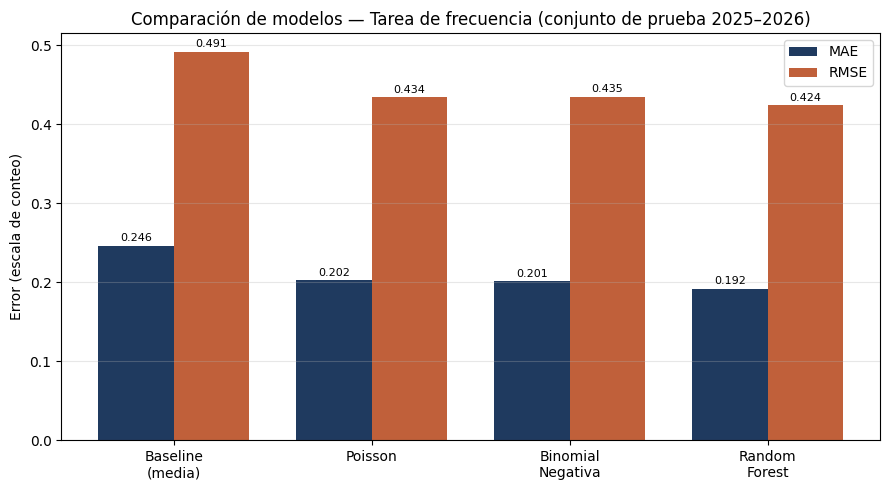


[OK] Figura guardada: reports/figures/nb04_comparacion_frecuencia.png


In [8]:
# === Sección 9 — Tabla comparativa de frecuencia ===
import matplotlib.pyplot as plt

# --- Construir tabla comparativa desde el dict acumulado ---
orden_freq = ["baseline_media", "poisson", "binomial_negativa", "random_forest"]
filas = []
for k in orden_freq:
    m = metricas_frecuencia[k]
    filas.append({
        "Modelo": m["modelo"],
        "MAE": m["MAE"],
        "RMSE": m["RMSE"],
        "AIC": m.get("AIC", np.nan),
    })
tabla_freq = pd.DataFrame(filas)

print("=== Tabla comparativa — Tarea de Frecuencia ===\n")
print(tabla_freq.to_string(index=False))

# Mejor modelo por cada criterio
mejor_mae  = tabla_freq.loc[tabla_freq["MAE"].idxmin(), "Modelo"]
mejor_rmse = tabla_freq.loc[tabla_freq["RMSE"].idxmin(), "Modelo"]
mejor_aic  = tabla_freq.loc[tabla_freq["AIC"].idxmin(), "Modelo"] if tabla_freq["AIC"].notna().any() else "N/A"
print(f"\nMejor MAE : {mejor_mae}")
print(f"Mejor RMSE: {mejor_rmse}")
print(f"Mejor AIC : {mejor_aic}")

# --- Gráfico de barras: MAE y RMSE por modelo ---
etiquetas = ["Baseline\n(media)", "Poisson", "Binomial\nNegativa", "Random\nForest"]
x = np.arange(len(etiquetas))
ancho = 0.38

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - ancho/2, tabla_freq["MAE"],  ancho, label="MAE",  color="#1F3A5F")
b2 = ax.bar(x + ancho/2, tabla_freq["RMSE"], ancho, label="RMSE", color="#C0603A")

ax.set_ylabel("Error (escala de conteo)")
ax.set_title("Comparación de modelos — Tarea de frecuencia (conjunto de prueba 2025–2026)")
ax.set_xticks(x)
ax.set_xticklabels(etiquetas)
ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()

# Guardar figura con la utilidad de config (versionada en reports/figures/)
cfg.save_fig(fig, "nb04_comparacion_frecuencia.png")
plt.show()
print("\n[OK] Figura guardada: reports/figures/nb04_comparacion_frecuencia.png")

## Sección 10 — Baseline de clase mayoritaria (severidad)

Comienza la tarea de clasificación de severidad. El primer modelo es el baseline más simple:
un clasificador que predice **siempre la clase mayoritaria** (`solo_danos`, 52% de los casos),
ignorando por completo las features. Cumple el mismo papel que el predictor de la media en la
tarea de frecuencia: fija el piso de desempeño contra el cual se juzgan los modelos reales.

**Por qué este baseline enseña algo importante.** Con un desbalance de 8.3× entre la clase
mayoritaria y la minoritaria (`fatal`, 6%), este predictor trivial alcanzará una accuracy
cercana al 52% —engañosamente parecida a "aprobado"— pese a no acertar **ni un solo** caso de
las clases `con_lesionados` y `fatal`. Esto demuestra de forma concreta por qué la accuracy es
una métrica insuficiente ante clases desbalanceadas: premia predecir siempre lo mismo.

Por eso la métrica principal de esta tarea es el **F1-macro**, que promedia el F1 de las tres
clases dándoles igual peso, sin importar su frecuencia. El baseline obtendrá un F1-macro muy
bajo, evidenciando que "acertar la mayoría" no equivale a "clasificar bien". Se reportan ambas
métricas (accuracy y F1-macro) para hacer visible esta diferencia.

In [9]:
# === Sección 10 — Baseline de clase mayoritaria (severidad) ===
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Diccionario acumulador de métricas de severidad (se vuelca a JSON en la Sección 15)
metricas_severidad = {}

# --- Modelo: predecir siempre la clase mayoritaria ---
dummy = DummyClassifier(strategy="most_frequent", random_state=cfg.SEED)
dummy.fit(Xtr_rf_b, y_train_b)   # usa cualquier X; ignora features por diseño
pred_dummy = dummy.predict(Xte_rf_b)

# --- Métricas ---
acc_dummy = accuracy_score(y_test_b, pred_dummy)
f1m_dummy = f1_score(y_test_b, pred_dummy, average="macro")

metricas_severidad["baseline_mayoritaria"] = {
    "modelo": "Baseline clase mayoritaria",
    "accuracy": round(acc_dummy, 6),
    "f1_macro": round(f1m_dummy, 6),
    "clase_predicha": str(dummy.classes_[dummy.predict(Xte_rf_b[:1])[0] == dummy.classes_][0])
        if False else "solo_danos",  # informativo
}

print(f"Clase predicha siempre: solo_danos")
print(f"Accuracy : {acc_dummy:.4f}   <- parece 'aprobado' por el desbalance")
print(f"F1-macro : {f1m_dummy:.4f}   <- revela que no clasifica: ignora 2 de 3 clases")

print("\n--- Reporte por clase ---")
print(classification_report(y_test_b, pred_dummy, zero_division=0))

Clase predicha siempre: solo_danos
Accuracy : 0.5158   <- parece 'aprobado' por el desbalance
F1-macro : 0.2268   <- revela que no clasifica: ignora 2 de 3 clases

--- Reporte por clase ---
                precision    recall  f1-score   support

con_lesionados       0.00      0.00      0.00     14457
         fatal       0.00      0.00      0.00      1897
    solo_danos       0.52      1.00      0.68     17420

      accuracy                           0.52     33774
     macro avg       0.17      0.33      0.23     33774
  weighted avg       0.27      0.52      0.35     33774



## Sección 11 — Regresión Logística multinomial (severidad)

La Regresión Logística multinomial extiende la regresión logística a más de dos clases:
estima, para cada siniestro, la probabilidad de pertenecer a cada uno de los tres niveles de
riesgo (`solo_danos`, `con_lesionados`, `fatal`) y asigna la clase más probable. Es el modelo
lineal e interpretable de esta tarea, análogo al papel que cumplió la Regresión de Poisson en
la tarea de frecuencia.

**Manejo del desbalance.** Dado el desbalance de 8.3× —que hizo fracasar al baseline en las
clases minoritarias—, se entrena con `class_weight='balanced'`. Esta opción pondera cada clase
de forma inversamente proporcional a su frecuencia: los errores sobre la clase `fatal` (rara)
pesan mucho más que los errores sobre `solo_danos` (común), obligando al modelo a "prestar
atención" a las clases minoritarias en lugar de ignorarlas. Es una alternativa al remuestreo
(sobre/submuestreo) que no altera los datos, solo la función de pérdida.

**Encoding.** Se usan las variables categóricas en formato **one-hot**, el que esperan los
modelos lineales.

**Configuración.** Se usa el solver `lbfgs` con un número de iteraciones suficiente para
converger. Como en toda la etapa baseline, no se optimizan hiperparámetros. Se reportan
accuracy y F1-macro, y el reporte por clase para observar específicamente el desempeño sobre
`fatal`.

In [10]:
# === Sección 11 — Regresión Logística multinomial (severidad) ===
from sklearn.linear_model import LogisticRegression

# --- Ajuste: multinomial + class_weight balanced + one-hot ---
logit = LogisticRegression(
    multi_class="multinomial",
    class_weight="balanced",
    solver="lbfgs",
    max_iter=2000,
    random_state=cfg.SEED,
    n_jobs=-1,
)
logit.fit(Xtr_ohe_b, y_train_b)

# --- Predicción ---
pred_logit = logit.predict(Xte_ohe_b)

# --- Métricas ---
acc_logit = accuracy_score(y_test_b, pred_logit)
f1m_logit = f1_score(y_test_b, pred_logit, average="macro")

metricas_severidad["logistica_multinomial"] = {
    "modelo": "Regresión Logística multinomial (class_weight=balanced)",
    "accuracy": round(acc_logit, 6),
    "f1_macro": round(f1m_logit, 6),
}

print(f"Accuracy : {acc_logit:.4f}   (baseline: {acc_dummy:.4f})")
print(f"F1-macro : {f1m_logit:.4f}   (baseline: {f1m_dummy:.4f})")

print("\n--- Reporte por clase ---")
print(classification_report(y_test_b, pred_logit, zero_division=0))

# --- Guardar modelo (.pkl) ---
ruta_logit = cfg.MODELS_DIR / "severidad_logistica.pkl"
joblib.dump(logit, ruta_logit)
print(f"[OK] Modelo guardado en: {ruta_logit}")

/Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy : 0.4049   (baseline: 0.5158)
F1-macro : 0.2781   (baseline: 0.2268)

--- Reporte por clase ---
                precision    recall  f1-score   support

con_lesionados       0.43      0.04      0.08     14457
         fatal       0.08      0.45      0.14      1897
    solo_danos       0.55      0.70      0.62     17420

      accuracy                           0.40     33774
     macro avg       0.36      0.40      0.28     33774
  weighted avg       0.47      0.40      0.36     33774

[OK] Modelo guardado en: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models/severidad_logistica.pkl


## Sección 12 — Random Forest Classifier (severidad)

El Random Forest Classifier es el modelo no lineal de la tarea de severidad. A diferencia de la
Regresión Logística —que traza fronteras lineales entre clases— el bosque combina muchos
árboles capaces de capturar interacciones y relaciones no lineales entre las features. Esto lo
hace especialmente prometedor para la clase intermedia `con_lesionados`, que la Logística casi
no logró detectar (recall 0.04) por compartir características tanto con `solo_danos` como con
`fatal`: una frontera no lineal podría separarla mejor.

**Manejo del desbalance.** Igual que en la Logística, se entrena con `class_weight='balanced'`
para que los errores sobre las clases minoritarias (`fatal`, `con_lesionados`) pesen más y el
modelo no colapse hacia la clase mayoritaria.

**Encoding.** Se usan los **códigos de categoría** (`.cat.codes`), suficientes para los árboles.

**Configuración.** Se emplean hiperparámetros por defecto razonables (`n_estimators=200`,
`random_state=cfg.SEED`, `n_jobs=-1`), consistentes con el Random Forest de la tarea de
frecuencia. La optimización se reserva para la Etapa 2. Se reportan accuracy, F1-macro y el
reporte por clase, con atención especial a si mejora la detección de `con_lesionados` respecto
a la Logística.

In [11]:
# === Sección 12 — Random Forest Classifier (severidad) ===
from sklearn.ensemble import RandomForestClassifier

# --- Ajuste: RF + class_weight balanced + cat.codes ---
rf_sev = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=cfg.SEED,
    n_jobs=-1,
)
rf_sev.fit(Xtr_rf_b, y_train_b)

# --- Predicción ---
pred_rf_sev = rf_sev.predict(Xte_rf_b)

# --- Métricas ---
acc_rf_sev = accuracy_score(y_test_b, pred_rf_sev)
f1m_rf_sev = f1_score(y_test_b, pred_rf_sev, average="macro")

metricas_severidad["random_forest"] = {
    "modelo": "Random Forest Classifier (class_weight=balanced)",
    "n_estimators": 200,
    "accuracy": round(acc_rf_sev, 6),
    "f1_macro": round(f1m_rf_sev, 6),
}

print(f"Accuracy : {acc_rf_sev:.4f}   (baseline: {acc_dummy:.4f} | Logística: {acc_logit:.4f})")
print(f"F1-macro : {f1m_rf_sev:.4f}   (baseline: {f1m_dummy:.4f} | Logística: {f1m_logit:.4f})")

print("\n--- Reporte por clase ---")
print(classification_report(y_test_b, pred_rf_sev, zero_division=0))

# --- Importancia de features (Gini) ---
importancias_sev = pd.Series(
    rf_sev.feature_importances_, index=Xtr_rf_b.columns
).sort_values(ascending=False)
print("Importancia de features (RF severidad):")
print(importancias_sev.round(4))

# --- Guardar modelo (.pkl) ---
ruta_rf_sev = cfg.MODELS_DIR / "severidad_random_forest.pkl"
joblib.dump(rf_sev, ruta_rf_sev)
print(f"\n[OK] Modelo guardado en: {ruta_rf_sev}")

Accuracy : 0.3940   (baseline: 0.5158 | Logística: 0.4049)
F1-macro : 0.3247   (baseline: 0.2268 | Logística: 0.2781)

--- Reporte por clase ---
                precision    recall  f1-score   support

con_lesionados       0.43      0.32      0.37     14457
         fatal       0.07      0.27      0.11      1897
    solo_danos       0.54      0.47      0.50     17420

      accuracy                           0.39     33774
     macro avg       0.34      0.35      0.32     33774
  weighted avg       0.46      0.39      0.42     33774

Importancia de features (RF severidad):
factor_causante_grp    0.3820
dia_semana             0.1734
tipo_vehiculo          0.1300
tipo_siniestro         0.1205
condicion_via          0.0904
es_lluviosa            0.0539
es_feriado             0.0196
es_finde               0.0194
periodo_agostino       0.0107
dtype: float64

[OK] Modelo guardado en: /Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/models/severidad_random_forest.pkl


## Sección 13 — Tabla comparativa de severidad

Se consolidan los tres modelos de la tarea de severidad, evaluados sobre el mismo conjunto de
prueba (2025–2026) con validación temporal.

**Métricas y por qué F1-macro.** Se reportan accuracy y F1-macro. Como se demostró con el
baseline, la accuracy es engañosa ante el desbalance de 8.3×: predecir siempre la clase
mayoritaria alcanza ~52% de accuracy sin clasificar nada. El **F1-macro** —que promedia el F1
de las tres clases con igual peso— es la métrica de referencia, porque sí penaliza ignorar las
clases minoritarias.

**Lectura de los resultados.** El ranking por F1-macro es: baseline (0.23) < Logística (0.28)
< Random Forest (0.32). El Random Forest es el mejor clasificador, y su ventaja proviene
principalmente de **recuperar la clase intermedia** `con_lesionados` (recall 0.04 en Logística
→ 0.32 en RF), que resultó linealmente inseparable para la Logística. Nótese que la accuracy
*disminuye* del baseline al RF: esto es esperado y correcto, pues los modelos con
`class_weight='balanced'` sacrifican acertar la clase fácil a cambio de detectar las clases
raras.

**Trade-off a declarar.** No existe un único "mejor" modelo en todos los sentidos: el Random
Forest gana en F1-macro (balance global), pero la Logística detecta más casos `fatal` (recall
0.45 vs 0.27), a costa de peor desempeño en el resto. La elección depende de la prioridad: si
se prioriza detectar fatalidades, la Logística; si se prioriza el balance entre las tres
clases, el Random Forest. Para este proyecto se adopta el Random Forest como modelo de
referencia por su mejor F1-macro.

**Matriz de confusión.** Se incluye la del Random Forest para visualizar dónde acierta y dónde
se confunde: en particular, cuánta de la confusión ocurre entre clases adyacentes
(`solo_danos` ↔ `con_lesionados` ↔ `fatal`), lo esperable en una variable de severidad
ordenada.

=== Tabla comparativa — Tarea de Severidad ===

                                                 Modelo  Accuracy  F1-macro
                             Baseline clase mayoritaria  0.515781  0.226850
Regresión Logística multinomial (class_weight=balanced)  0.404897  0.278118
       Random Forest Classifier (class_weight=balanced)  0.393972  0.324721

Mejor F1-macro: Random Forest Classifier (class_weight=balanced)


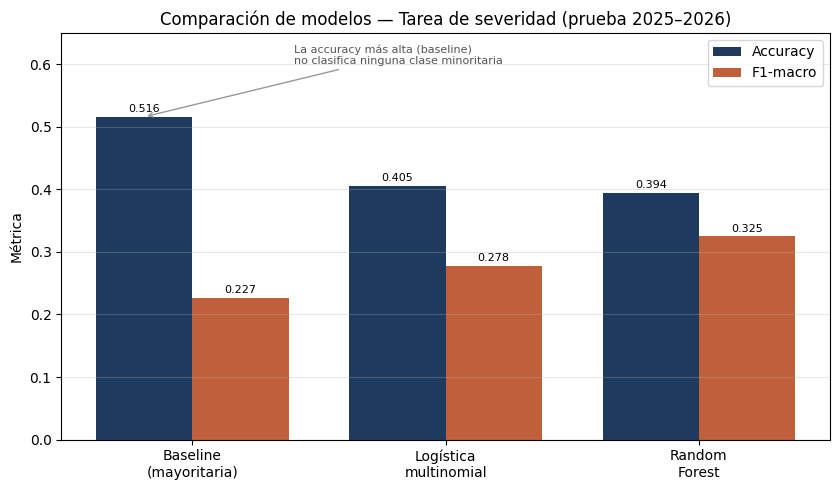

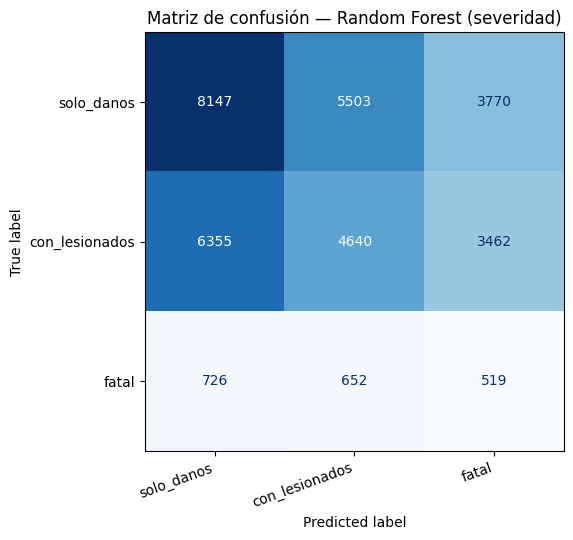


[OK] Figuras guardadas: nb04_comparacion_severidad.png, nb04_matriz_confusion_rf_severidad.png


In [12]:
# === Sección 13 — Tabla comparativa de severidad ===

# --- Construir tabla comparativa desde el dict acumulado ---
orden_sev = ["baseline_mayoritaria", "logistica_multinomial", "random_forest"]
filas_sev = []
for k in orden_sev:
    m = metricas_severidad[k]
    filas_sev.append({
        "Modelo": m["modelo"],
        "Accuracy": m["accuracy"],
        "F1-macro": m["f1_macro"],
    })
tabla_sev = pd.DataFrame(filas_sev)

print("=== Tabla comparativa — Tarea de Severidad ===\n")
print(tabla_sev.to_string(index=False))

mejor_f1m = tabla_sev.loc[tabla_sev["F1-macro"].idxmax(), "Modelo"]
print(f"\nMejor F1-macro: {mejor_f1m}")

# --- Gráfico 1: barras Accuracy vs F1-macro por modelo ---
etiquetas_s = ["Baseline\n(mayoritaria)", "Logística\nmultinomial", "Random\nForest"]
x = np.arange(len(etiquetas_s))
ancho = 0.38

fig, ax = plt.subplots(figsize=(8.5, 5))
b1 = ax.bar(x - ancho/2, tabla_sev["Accuracy"], ancho, label="Accuracy", color="#1F3A5F")
b2 = ax.bar(x + ancho/2, tabla_sev["F1-macro"], ancho, label="F1-macro", color="#C0603A")
ax.set_ylabel("Métrica")
ax.set_title("Comparación de modelos — Tarea de severidad (prueba 2025–2026)")
ax.set_xticks(x); ax.set_xticklabels(etiquetas_s)
ax.set_ylim(0, 0.65)
ax.legend()
ax.bar_label(b1, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.3f", padding=2, fontsize=8)
ax.grid(axis="y", alpha=0.3)
# Anotación didáctica: accuracy engaña
ax.annotate("La accuracy más alta (baseline)\nno clasifica ninguna clase minoritaria",
            xy=(0 - ancho/2, tabla_sev["Accuracy"].iloc[0]), xytext=(0.4, 0.60),
            fontsize=8, color="#555",
            arrowprops=dict(arrowstyle="->", color="#999"))
fig.tight_layout()
cfg.save_fig(fig, "nb04_comparacion_severidad.png")
plt.show()

# --- Gráfico 2: matriz de confusión del RF (mejor F1-macro) ---
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_b, pred_rf_sev, labels=CLASES_B)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASES_B)
disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title("Matriz de confusión — Random Forest (severidad)")
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
fig.tight_layout()
cfg.save_fig(fig, "nb04_matriz_confusion_rf_severidad.png")
plt.show()

print("\n[OK] Figuras guardadas: nb04_comparacion_severidad.png, nb04_matriz_confusion_rf_severidad.png")

## Sección 14 — Interpretabilidad (SHAP y LIME)

Los modelos de la sección anterior predicen, pero no explican *por qué* predicen. La
interpretabilidad busca abrir esa "caja negra" —especialmente la del Random Forest, que a
diferencia de los GLM no entrega coeficientes legibles— para entender qué variables impulsan
las predicciones y en qué dirección. Se emplean dos técnicas complementarias.

### SHAP — explicación global

**SHAP** (SHapley Additive exPlanations) se basa en la teoría de juegos cooperativos: reparte
la predicción entre las features asignando a cada una una contribución justa, según cuánto
aporta en todas las combinaciones posibles. Aplicado a todo el conjunto, da una visión
**global**: qué variables mandan en el modelo y cómo empujan las predicciones hacia arriba o
hacia abajo.

SHAP tiene una ventaja decisiva sobre la importancia por impureza (Gini) que reportamos junto a
cada Random Forest: **corrige el sesgo de Gini**. La importancia por impureza favorece
artificialmente a las variables continuas con muchos valores distintos (más puntos de corte
posibles) y penaliza a las binarias. Esto ya generó lecturas sospechosas —`prcp_mensual`
apareció 2ª en frecuencia pese a tener un efecto minúsculo en Poisson; `dia_semana` apareció
2ª en severidad—. SHAP, al medir la contribución real a las predicciones, permite verificar si
esos rankings se sostienen o eran un artefacto de la métrica.

Se usa `TreeExplainer`, el algoritmo de SHAP específico para modelos de árbol: exacto y
eficiente. Por costo computacional, el análisis se realiza sobre una muestra aleatoria
representativa del conjunto de prueba (con semilla fija), práctica estándar que no altera el
patrón global.

### LIME — explicación local

**LIME** (Local Interpretable Model-agnostic Explanations) responde una pregunta distinta: no
"¿qué importa en el modelo en general?" sino "¿por qué *este caso concreto* se predijo así?".
Para un siniestro individual, LIME aproxima el modelo con uno lineal simple en el entorno de
ese punto, mostrando qué features empujaron la predicción hacia la clase asignada.

Se aplica LIME a un caso individual de la tarea de severidad —un siniestro clasificado como
`fatal`— para ilustrar el razonamiento del modelo a nivel de instancia, complementando la
visión global de SHAP con una visión local.

### Sobre qué modelos se aplica

SHAP se aplica sobre los dos Random Forest (frecuencia y severidad), por ser los mejores
modelos predictivos de cada tarea y los más opacos. LIME se aplica sobre un caso del Random
Forest de severidad. Los GLM (Poisson, Binomial Negativa) ya son interpretables mediante sus
coeficientes exponenciados (Sección 6), por lo que no requieren estas técnicas.

### 14.2 — SHAP global: Random Forest de frecuencia

Se aplica `TreeExplainer` sobre el Random Forest de frecuencia para obtener la contribución
real de cada feature a las predicciones de conteo. El *summary plot* (beeswarm) ordena las
variables por importancia SHAP (media del valor absoluto) y muestra, para cada una, cómo sus
valores altos o bajos empujan la predicción.

El objetivo específico es **contrastar este ranking con el de importancia por impureza (Gini)**
reportado en la Sección 8, donde `prcp_mensual` apareció en segundo lugar pese a tener un
efecto minúsculo en el modelo de Poisson (exp(coef)=1.0005). Si SHAP la desplaza hacia abajo,
confirmaría que aquella posición era un artefacto del sesgo de Gini hacia variables continuas,
y no una influencia real.

**Nota de cómputo.** El Random Forest de frecuencia se entrenó con árboles sin poda (profundidad
libre) sobre 451k filas; calcular SHAP exacto sobre ellos es costoso. Por eso el análisis se
realiza sobre una muestra aleatoria reducida del conjunto de prueba (500 observaciones, semilla
fija), suficiente para el patrón global, y se desactiva la verificación de aditividad
(`check_additivity=False`) para acelerar sin alterar los valores SHAP reportados.

shap version: 0.46.0
SHAP calculado en 207.5 s sobre 500 filas


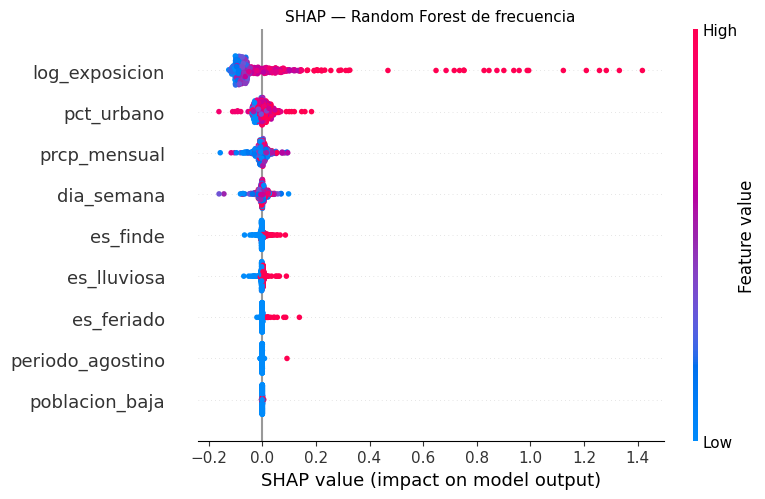


Ranking de importancia SHAP (frecuencia):
log_exposicion      0.1109
pct_urbano          0.0212
prcp_mensual        0.0160
dia_semana          0.0116
es_finde            0.0066
es_lluviosa         0.0047
es_feriado          0.0022
periodo_agostino    0.0009
poblacion_baja      0.0001
dtype: float64

Comparar con Gini (Sección 8): log_exposicion 0.69, prcp_mensual 0.14, dia_semana 0.08...


In [13]:
# === Sección 14.2 — SHAP global: Random Forest de frecuencia ===
import time

# Import defensivo: verifica que shap cargue correctamente
try:
    import shap
    print(f"shap version: {shap.__version__}")
except Exception as e:
    raise ImportError(
        f"No se pudo importar shap ({e}). Verificar instalación: pip install shap==0.46.0"
    )

# --- Muestra reducida del test (500 basta para el patrón global) ---
N_SHAP = 500
rng = np.random.default_rng(cfg.SEED)
idx_shap_freq = rng.choice(len(Xte_rf_freq), size=min(N_SHAP, len(Xte_rf_freq)), replace=False)
X_shap_freq = Xte_rf_freq.iloc[idx_shap_freq]

# --- TreeExplainer (exacto para árboles); check_additivity=False para acelerar ---
t0 = time.time()
explainer_freq = shap.TreeExplainer(rf_freq)
shap_values_freq = explainer_freq.shap_values(X_shap_freq, check_additivity=False)
print(f"SHAP calculado en {time.time()-t0:.1f} s sobre {N_SHAP} filas")

# --- Summary plot (beeswarm) ---
fig = plt.figure()
shap.summary_plot(shap_values_freq, X_shap_freq, show=False)
plt.title("SHAP — Random Forest de frecuencia", fontsize=11)
plt.tight_layout()
cfg.save_fig(plt.gcf(), "nb04_shap_frecuencia.png")
plt.show()

# --- Ranking SHAP (media del valor absoluto) para comparar con Gini ---
shap_abs_mean = pd.Series(
    np.abs(shap_values_freq).mean(axis=0), index=X_shap_freq.columns
).sort_values(ascending=False)
print("\nRanking de importancia SHAP (frecuencia):")
print(shap_abs_mean.round(4))
print("\nComparar con Gini (Sección 8): log_exposicion 0.69, prcp_mensual 0.14, dia_semana 0.08...")

### 14.3 — SHAP global: Random Forest de severidad

Se aplica `TreeExplainer` sobre el Random Forest de severidad. A diferencia de la tarea de
frecuencia (regresión, un único valor SHAP por observación), en clasificación multiclase SHAP
produce un conjunto de valores **por cada clase** (`solo_danos`, `con_lesionados`, `fatal`):
para cada predicción, muestra cómo cada feature empuja hacia o en contra de cada clase.

Se reporta el ranking de importancia SHAP **global** (promediando la magnitud de la
contribución sobre las tres clases) y el summary plot correspondiente. El objetivo es doble:

1. **Confirmar el factor real dominante.** La importancia por impureza (Sección 12) situó a
   `factor_causante_grp` primero (0.38), lo cual es sustantivamente lógico (el motivo del
   accidente condiciona su gravedad). SHAP debería confirmarlo.
2. **Verificar `dia_semana`.** En Gini apareció segundo (0.17), sospechosamente alto para una
   variable de calendario en una tarea de *gravedad* (el calendario influye en la *frecuencia*,
   no tanto en la severidad individual). Si SHAP la desplaza hacia abajo, sería otra
   manifestación del sesgo de Gini hacia variables con muchos valores, como ocurrió con
   `prcp_mensual` en frecuencia.

Como en 14.2, se usa una muestra reducida del conjunto de prueba (semilla fija) por eficiencia.

SHAP calculado en 113.2 s sobre 500 filas

Ranking de importancia SHAP global (severidad, promedio sobre 3 clases):
tipo_vehiculo          0.0450
factor_causante_grp    0.0372
dia_semana             0.0268
tipo_siniestro         0.0248
es_lluviosa            0.0197
condicion_via          0.0194
es_finde               0.0106
es_feriado             0.0047
periodo_agostino       0.0016
dtype: float64

Comparar con Gini (Sección 12): factor_causante_grp 0.38, dia_semana 0.17, tipo_vehiculo 0.13...


<Figure size 640x480 with 0 Axes>

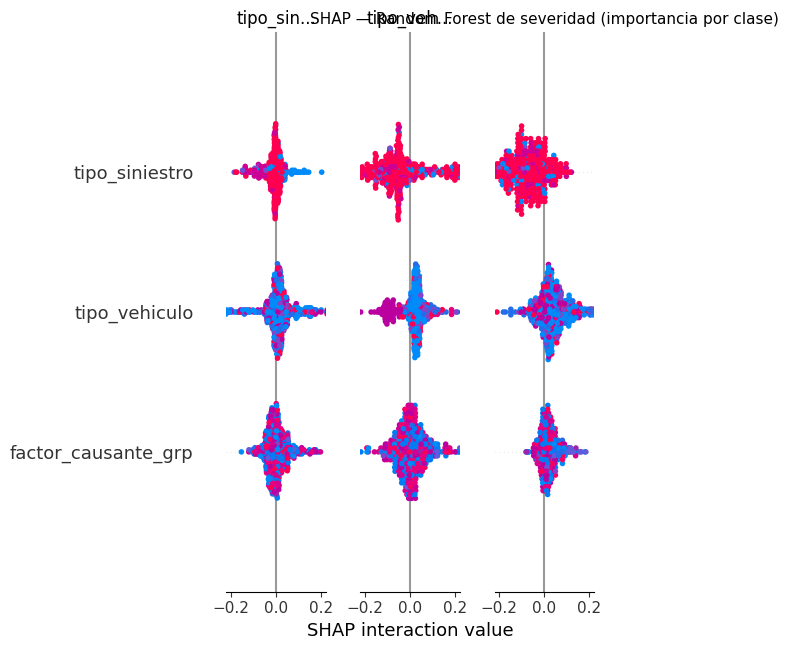

In [14]:
# === Sección 14.3 — SHAP global: Random Forest de severidad ===

# --- Muestra reducida del test de severidad ---
N_SHAP_B = 500
rng_b = np.random.default_rng(cfg.SEED)
idx_shap_sev = rng_b.choice(len(Xte_rf_b), size=min(N_SHAP_B, len(Xte_rf_b)), replace=False)
X_shap_sev = Xte_rf_b.iloc[idx_shap_sev]

# --- TreeExplainer (clasificación: devuelve valores por clase) ---
t0 = time.time()
explainer_sev = shap.TreeExplainer(rf_sev)
shap_values_sev = explainer_sev.shap_values(X_shap_sev, check_additivity=False)
print(f"SHAP calculado en {time.time()-t0:.1f} s sobre {N_SHAP_B} filas")

# shap_values_sev puede ser: lista de 3 arrays (una por clase) o array 3D (n, features, clases)
# Se normaliza a "importancia global" = media de |SHAP| sobre observaciones y clases.
if isinstance(shap_values_sev, list):
    # lista de arrays (n_obs, n_features), una por clase
    abs_por_clase = [np.abs(sv).mean(axis=0) for sv in shap_values_sev]
    shap_abs_global = np.mean(abs_por_clase, axis=0)
    clases_orden = list(rf_sev.classes_)
else:
    # array 3D (n_obs, n_features, n_clases)
    shap_abs_global = np.abs(shap_values_sev).mean(axis=(0, 2))
    clases_orden = list(rf_sev.classes_)

ranking_shap_sev = pd.Series(
    shap_abs_global, index=X_shap_sev.columns
).sort_values(ascending=False)

print("\nRanking de importancia SHAP global (severidad, promedio sobre 3 clases):")
print(ranking_shap_sev.round(4))
print("\nComparar con Gini (Sección 12): factor_causante_grp 0.38, dia_semana 0.17, tipo_vehiculo 0.13...")

# --- Summary plot ---
# Para multiclase, shap.summary_plot con la lista dibuja barras apiladas por clase.
fig = plt.figure()
shap.summary_plot(
    shap_values_sev, X_shap_sev,
    class_names=clases_orden, show=False, plot_type="bar"
)
plt.title("SHAP — Random Forest de severidad (importancia por clase)", fontsize=11)
plt.tight_layout()
cfg.save_fig(plt.gcf(), "nb04_shap_severidad.png")
plt.show()

### 14.4 — LIME local: explicación de casos individuales

SHAP entregó la visión global (qué features importan en promedio). LIME aporta la visión
**local**: toma un siniestro individual y explica por qué el modelo lo clasificó como lo hizo,
aproximando el Random Forest con un modelo lineal simple en el vecindario de ese punto.

Se analizan **dos casos** de la tarea de severidad, ambos predichos como `fatal`, para una
interpretación completa y honesta:

- **Caso A — acierto:** un siniestro que era realmente `fatal` y que el modelo clasificó
  correctamente. Muestra qué señales llevan al modelo a una predicción acertada de gravedad.
- **Caso B — error:** un siniestro que era `solo_danos` pero que el modelo predijo como `fatal`
  (un falso positivo). Es especialmente instructivo: ilustra a nivel de instancia el mismo
  patrón que la matriz de confusión mostró en agregado —el modelo, al carecer de información
  sobre las víctimas, se apoya en señales indirectas del siniestro y tiende a sobre-predecir
  `fatal`—. Explicar un error, y no solo un acierto, evidencia comprensión de las limitaciones
  del modelo.

Se usa `LimeTabularExplainer` sobre la representación por códigos de categoría que consume el
Random Forest. Para legibilidad, los códigos numéricos se traducen a sus etiquetas originales.


CASO A — Acierto (fatal correcto)  (fila 127 del test)
  Clase real     : fatal
  Clase predicha : fatal
  Valores del siniestro:
    factor_causante_grp   : No Respetar Señales de Tránsito
    tipo_siniestro        : Atropello
    tipo_vehiculo         : Automovil
    condicion_via         : Seca
    es_lluviosa           : 0
    es_finde              : 1
    dia_semana            : 4
    periodo_agostino      : 0
    es_feriado            : 0

  Contribuciones LIME (hacia 'fatal'):
    empuja A favor  | es_feriado=0                        (peso +0.1034)
    empuja A favor  | condicion_via=Seca                  (peso +0.0757)
    empuja A favor  | periodo_agostino=0                  (peso +0.0569)
    empuja EN contra | es_lluviosa=0                       (peso -0.0248)
    empuja A favor  | factor_causante_grp=No Respetar Señales de Tránsito (peso +0.0175)
    empuja A favor  | es_finde=1                          (peso +0.0070)
    empuja A favor  | dia_semana=4                     

/Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


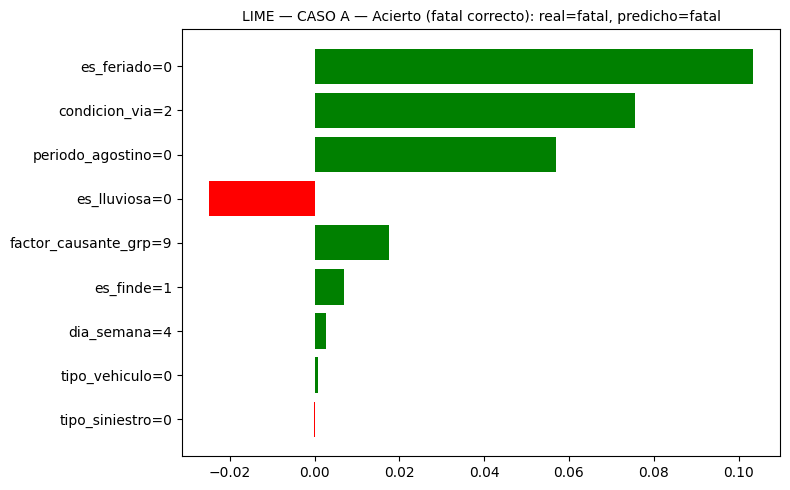


CASO B — Error (falso positivo de fatal)  (fila 10 del test)
  Clase real     : solo_danos
  Clase predicha : fatal
  Valores del siniestro:
    factor_causante_grp   : Otros
    tipo_siniestro        : Colision
    tipo_vehiculo         : Automovil
    condicion_via         : Seca
    es_lluviosa           : 0
    es_finde              : 0
    dia_semana            : 2
    periodo_agostino      : 0
    es_feriado            : 1

  Contribuciones LIME (hacia 'fatal'):
    empuja EN contra | es_feriado=1                        (peso -0.1027)
    empuja A favor  | condicion_via=Seca                  (peso +0.0723)
    empuja A favor  | tipo_siniestro=Colision             (peso +0.0678)
    empuja A favor  | periodo_agostino=0                  (peso +0.0569)
    empuja EN contra | es_lluviosa=0                       (peso -0.0244)
    empuja EN contra | dia_semana=2                        (peso -0.0134)
    empuja EN contra | factor_causante_grp=Otros           (peso -0.0123)
    empuja 

/Users/jpurquilla/Desktop/Trabajo de Grado/Etapa 1/siniestralidad-vial-sv/.venv/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


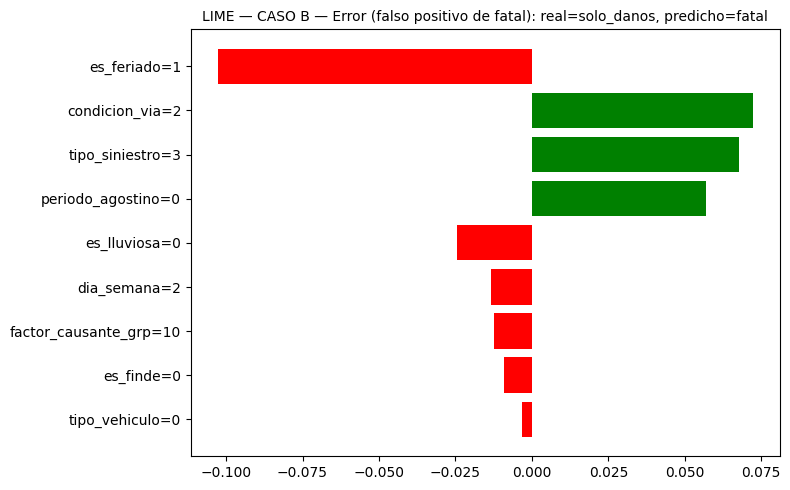


[OK] Figuras guardadas: nb04_lime_caso_A_acierto.png, nb04_lime_caso_B_error.png


In [16]:
# === Sección 14.4 — LIME local: dos casos (acierto y error) ===
from lime.lime_tabular import LimeTabularExplainer

# --- Diccionario código -> etiqueta para cada categórica (legibilidad) ---
codigo_a_etiqueta = {}
for c in CAT_B:
    cats = cat_dtypes_b[c].categories
    codigo_a_etiqueta[c] = {i: str(cat) for i, cat in enumerate(cats)}

def traducir_feature(nombre_regla):
    """Convierte 'condicion_via=2' -> 'condicion_via=Humeda' usando el diccionario."""
    for c in CAT_B:
        pref = f"{c}="
        if nombre_regla.startswith(pref):
            try:
                cod = int(float(nombre_regla.split("=")[1]))
                etq = codigo_a_etiqueta[c].get(cod, cod)
                return f"{c}={etq}"
            except (ValueError, IndexError):
                return nombre_regla
    return nombre_regla  # binarias/numéricas quedan igual

# --- Explainer LIME ---
clases_rf = list(rf_sev.classes_)
explainer_lime = LimeTabularExplainer(
    training_data=Xtr_rf_b.to_numpy(),
    feature_names=list(Xtr_rf_b.columns),
    class_names=clases_rf,
    mode="classification",
    categorical_features=list(range(Xtr_rf_b.shape[1])),
    random_state=cfg.SEED,
)

pred_test_sev = rf_sev.predict(Xte_rf_b)

# --- Seleccionar los dos casos ---
# Caso A (acierto): real=fatal Y predicho=fatal
mask_acierto = (pred_test_sev == "fatal") & (y_test_b.to_numpy() == "fatal")
# Caso B (error): real=solo_danos pero predicho=fatal (falso positivo)
mask_error = (pred_test_sev == "fatal") & (y_test_b.to_numpy() == "solo_danos")

idx_A = np.where(mask_acierto)[0][0]
idx_B = np.where(mask_error)[0][0]

def explicar_caso(idx, etiqueta_caso):
    x = Xte_rf_b.iloc[idx]
    real = y_test_b.iloc[idx]
    pred = pred_test_sev[idx]
    print(f"\n{'='*60}")
    print(f"{etiqueta_caso}  (fila {idx} del test)")
    print(f"  Clase real     : {real}")
    print(f"  Clase predicha : {pred}")
    print(f"  Valores del siniestro:")
    for col in Xte_rf_b.columns:
        print(f"    {col:22s}: {test_b.iloc[idx][col]}")

    exp = explainer_lime.explain_instance(
        data_row=x.to_numpy(),
        predict_fn=rf_sev.predict_proba,
        num_features=len(Xtr_rf_b.columns),
        top_labels=1,
    )
    idx_clase = clases_rf.index(pred)
    print(f"\n  Contribuciones LIME (hacia '{pred}'):")
    for feat, peso in exp.as_list(label=idx_clase):
        signo = "empuja A favor " if peso > 0 else "empuja EN contra"
        print(f"    {signo} | {traducir_feature(feat):35s} (peso {peso:+.4f})")

    fig = exp.as_pyplot_figure(label=idx_clase)
    fig.set_size_inches(8, 5)
    plt.title(f"LIME — {etiqueta_caso}: real={real}, predicho={pred}", fontsize=10)
    plt.tight_layout()
    return exp, fig

# --- Caso A: acierto ---
exp_A, fig_A = explicar_caso(idx_A, "CASO A — Acierto (fatal correcto)")
cfg.save_fig(fig_A, "nb04_lime_caso_A_acierto.png")
plt.show()

# --- Caso B: error (falso positivo) ---
exp_B, fig_B = explicar_caso(idx_B, "CASO B — Error (falso positivo de fatal)")
cfg.save_fig(fig_B, "nb04_lime_caso_B_error.png")
plt.show()

print(f"\n[OK] Figuras guardadas: nb04_lime_caso_A_acierto.png, nb04_lime_caso_B_error.png")

## Sección 15 — Persistencia de métricas

Los modelos entrenados se guardaron en formato `.pkl` a medida que se ajustaron (uno por
sección), en `cfg.MODELS_DIR`. Resta consolidar las **métricas** de ambas tareas en un único
archivo `.json`, siguiendo la convención del proyecto (modelos en `.pkl`, métricas en `.json`).

**Por qué JSON.** Es un formato de texto legible y estructurado: permite revisar los resultados
directamente (incluso en GitHub, sin ejecutar código), preserva la jerarquía natural de las
métricas (modelo → {MAE, RMSE, AIC, ...}), separa los resultados de los modelos binarios, y es
portable a cualquier herramienta. Esto contribuye al criterio de reproducibilidad de la
rúbrica y facilita citar las métricas en el documento final y compararlas con los modelos
avanzados de la Etapa 2.

Se guarda un único objeto con dos secciones (frecuencia y severidad), cada una con todos sus
modelos y métricas.

In [17]:
# === Sección 15 — Persistencia de métricas ===
import json

# --- Consolidar métricas de ambas tareas en un único objeto ---
metricas_nb04 = {
    "notebook": "NB04_modelos_baseline",
    "seed": cfg.SEED,
    "tarea_frecuencia": {
        "descripcion": "Regresión de conteo (distrito x fecha x franja). Métricas en escala de conteo.",
        "metrica_principal": "MAE / RMSE",
        "modelos": metricas_frecuencia,
    },
    "tarea_severidad": {
        "descripcion": "Clasificación 3 clases (solo_danos/con_lesionados/fatal). Desbalance 8.3x.",
        "metrica_principal": "F1-macro (accuracy secundaria por desbalance)",
        "modelos": metricas_severidad,
    },
}

# --- Guardar con la utilidad de config ---
cfg.save_metrics(metricas_nb04, "nb04_metricas_baseline.json")

# --- Verificación: releer y mostrar ---
ruta_metricas = cfg.METRICS_DIR / "nb04_metricas_baseline.json" if hasattr(cfg, "METRICS_DIR") else None
print("Métricas consolidadas guardadas.\n")
print(json.dumps(metricas_nb04, indent=2, ensure_ascii=False))

# --- Confirmar modelos .pkl presentes en disco ---
print("\n--- Modelos .pkl guardados en cfg.MODELS_DIR ---")
for pkl in sorted(cfg.MODELS_DIR.glob("*.pkl")):
    print(f"  {pkl.name}  ({pkl.stat().st_size/1024:.1f} KB)")

Métricas consolidadas guardadas.

{
  "notebook": "NB04_modelos_baseline",
  "seed": 42,
  "tarea_frecuencia": {
    "descripcion": "Regresión de conteo (distrito x fecha x franja). Métricas en escala de conteo.",
    "metrica_principal": "MAE / RMSE",
    "modelos": {
      "baseline_media": {
        "modelo": "Predictor ingenuo (media)",
        "constante_predicha": 0.124398,
        "MAE": 0.246301,
        "RMSE": 0.491455
      },
      "poisson": {
        "modelo": "Regresión de Poisson (offset log_exposicion)",
        "MAE": 0.202224,
        "RMSE": 0.434255,
        "AIC": 289662.08,
        "log_likelihood": -144818.04
      },
      "binomial_negativa": {
        "modelo": "Regresión Binomial Negativa (offset log_exposicion)",
        "alpha": 1.0,
        "MAE": 0.201136,
        "RMSE": 0.435272,
        "AIC": 289004.73,
        "log_likelihood": -144489.36
      },
      "random_forest": {
        "modelo": "Random Forest Regressor (log_exposicion como feature)",
   

In [19]:
# Confirmar ubicación del JSON de métricas
for p in cfg.PROCESSED_DIR.parent.rglob("nb04_metricas_baseline.json"):
    print("JSON en:", p, f"({p.stat().st_size/1024:.1f} KB)")

### 15.1 — Optimización del tamaño de los modelos para control de versiones

Al inspeccionar los archivos `.pkl` se detectó que los modelos GLM (Poisson y Binomial
Negativa) pesaban ~208 MB cada uno, pese a consistir únicamente en un conjunto de
coeficientes. La causa es que `statsmodels` conserva, dentro del objeto ajustado, una
referencia a la matriz de datos de entrenamiento (451,552 filas). Los Random Forest, por su
parte, son grandes por razones legítimas (200 árboles sin poda), pero se benefician de la
compresión.

Este tamaño es un problema para la reproducibilidad en GitHub, que rechaza archivos mayores a
100 MB. Se aplican dos optimizaciones:

- **GLM (Poisson, Binomial Negativa):** se eliminan los datos de entrenamiento embebidos con
  `remove_data()` antes de serializar. El modelo conserva sus coeficientes y capacidad de
  predicción; solo pierde la referencia a los datos crudos, que no son necesarios para predecir.
- **Random Forest (frecuencia y severidad):** se reserializan con compresión (`compress=3`),
  que reduce el tamaño en disco sin afectar el modelo.

Tras la optimización se verifica que los modelos reguardados siguen prediciendo idénticamente.

In [20]:
# === Sección 15.1 — Optimización del tamaño de los modelos ===

# --- 1) GLM: eliminar datos embebidos antes de reguardar ---
# Guardamos una predicción de control ANTES para verificar que no cambia nada.
ctrl_poisson_antes = poisson_model.predict(Xte_glm[:5], offset=offset_test_a[:5])
ctrl_nb_antes      = nb_model.predict(Xte_glm[:5], offset=offset_test_a[:5])

poisson_model.remove_data()
nb_model.remove_data()
joblib.dump(poisson_model, cfg.MODELS_DIR / "frecuencia_poisson.pkl")
joblib.dump(nb_model,      cfg.MODELS_DIR / "frecuencia_binomial_negativa.pkl")

# --- 2) Random Forest: reguardar con compresión ---
joblib.dump(rf_freq, cfg.MODELS_DIR / "frecuencia_random_forest.pkl", compress=3)
joblib.dump(rf_sev,  cfg.MODELS_DIR / "severidad_random_forest.pkl",  compress=3)
# La Logística ya es pequeña; la recomprimimos por consistencia
joblib.dump(logit,   cfg.MODELS_DIR / "severidad_logistica.pkl",      compress=3)

# --- 3) Verificar tamaños tras la optimización ---
print("--- Tamaños tras optimización ---")
total = 0
for pkl in sorted(cfg.MODELS_DIR.glob("*.pkl")):
    kb = pkl.stat().st_size / 1024
    total += kb
    flag = "  <-- >100MB, revisar" if kb > 100_000 else ""
    print(f"  {pkl.name:38s} {kb:>10.1f} KB{flag}")
print(f"  {'TOTAL':38s} {total:>10.1f} KB  ({total/1024:.1f} MB)")

# --- 4) Verificar que los GLM siguen prediciendo idéntico ---
poisson_recargado = joblib.load(cfg.MODELS_DIR / "frecuencia_poisson.pkl")
ctrl_poisson_desp = poisson_recargado.predict(Xte_glm[:5], offset=offset_test_a[:5])
print("\nVerificación Poisson (predicciones idénticas tras remove_data):",
      bool(np.allclose(ctrl_poisson_antes, ctrl_poisson_desp)))

--- Tamaños tras optimización ---
  frecuencia_binomial_negativa.pkl           3533.9 KB
  frecuencia_poisson.pkl                     3534.8 KB
  frecuencia_random_forest.pkl             124401.3 KB  <-- >100MB, revisar
  severidad_logistica.pkl                       1.9 KB
  severidad_random_forest.pkl               59212.4 KB
  TOTAL                                    190684.4 KB  (186.2 MB)

Verificación Poisson (predicciones idénticas tras remove_data): True


## Sección 16 — Conclusiones y cierre de la Etapa 1

### 16.1 — Resumen de resultados

Este notebook estableció modelos baseline para dos tareas de predicción sobre siniestralidad
vial, evaluados con validación temporal (entrenamiento 2022–2024, prueba 2025–2026).

**Tarea de frecuencia (regresión de conteo).** Los cuatro modelos superaron al predictor
ingenuo, confirmando que las features aportan señal. El Random Forest obtuvo el mejor poder
predictivo puntual (MAE 0.192, RMSE 0.424), mientras que la Binomial Negativa resultó el mejor
modelo estadístico: ganó la comparación por AIC frente a Poisson por 657 puntos, confirmando la
sobredispersión detectada en el EDA (índice 1.54) y validando la ruta metodológica anticipada
en el anteproyecto (Poisson → Binomial Negativa por AIC). La conclusión es doble: el Random
Forest es la mejor herramienta de *predicción*; la Binomial Negativa, el mejor modelo
*explicativo* (coeficientes interpretables e intervalos de predicción confiables).

Los coeficientes de Poisson cuantificaron y confirmaron los hallazgos del EDA: pico agostino
+40%, feriados +16% neto, mayor urbanización asociada a mucha mayor siniestralidad, y un efecto
mínimo de la precipitación puntual —coherente con que la señal climática vive en la temporada,
no en los milímetros diarios—.

**Tarea de severidad (clasificación multiclase).** Con desbalance 8.3×, la accuracy se mostró
engañosa (el baseline de clase mayoritaria alcanza 52% sin clasificar nada), por lo que se
adoptó F1-macro como métrica principal. El Random Forest fue el mejor clasificador
(F1-macro 0.325), superando a la Logística sobre todo por recuperar la clase intermedia
`con_lesionados` (recall 0.04 → 0.32), linealmente inseparable para la Logística. Se documentó
el trade-off honesto: la Logística detecta más casos `fatal` (recall 0.45 vs 0.27), a costa del
balance global. La clase `fatal` resultó difícil para ambos modelos, un techo esperable dado
que se predice *ex-ante*, sin información sobre las víctimas (excluida por anti-leakage).

**Interpretabilidad.** SHAP (global) permitió corregir el sesgo de la importancia por impureza:
la precipitación, que aparecía segunda por Gini, se reveló de peso mínimo —coincidiendo con el
coeficiente de Poisson—, y lo mismo ocurrió con `dia_semana` en severidad. LIME (local) mostró
el razonamiento del modelo en casos individuales, incluido un falso positivo de `fatal` que
ilustró, a nivel de instancia, la limitación estructural de predecir gravedad sin datos de
víctima.

### 16.2 — Ranking de distritos de alto riesgo

Uno de los objetivos del anteproyecto es **identificar zonas de alto riesgo**. El modelo de
frecuencia permite cumplirlo a nivel de distrito: agregando las predicciones de siniestros por
distrito sobre el período de prueba, se obtiene un ranking de los distritos con mayor
siniestralidad esperada.

Se usa la **Binomial Negativa** (modelo estadístico de referencia de la tarea de frecuencia)
para generar las predicciones, y se comparan con los conteos reales observados en el mismo
período, para verificar que el ranking es coherente con la realidad. El resultado es un insumo
directo para la priorización de intervenciones de seguridad vial y para el prototipo de
visualización previsto en la Etapa 2.

Cabe recordar el alcance definido en NB03: las predicciones son válidas para los 103 distritos
con presencia en la fuente de siniestros; la expansión de cobertura al resto del país es una
línea futura.

Distritos evaluados: 103

=== Top 15 distritos de mayor riesgo (predicho, período de prueba 2025-2026) ===

                siniestros_predichos  siniestros_observados
distrito                                                   
san salvador                  2231.8                   4116
soyapango                     1554.7                   1439
santa ana                     1483.2                   2034
san miguel                    1343.3                   2919
mejicanos                      920.9                    962
colon                          864.8                    871
apopa                          860.5                    648
santa tecla                    790.4                   2396
ciudad delgado                 716.1                    641
ahuachapan                     697.9                    477
ilopango                       594.7                    567
san martin                     581.3                    462
tonacatepeque                  573.3                

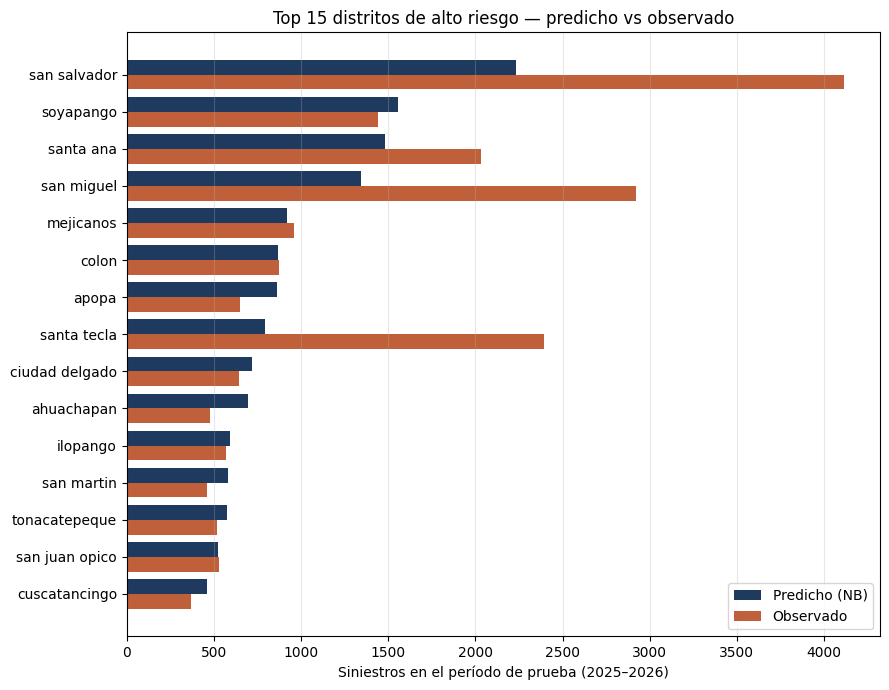


[OK] Figura guardada: nb04_ranking_distritos_riesgo.png


In [23]:
# === Sección 16.2 — Ranking de distritos de alto riesgo ===

# --- Predicción de la Binomial Negativa sobre el test (escala de conteo) ---
pred_nb_test = nb_model.predict(Xte_glm, offset=offset_test_a)

# --- Ensamblar distrito + predicho + observado por celda ---
ranking_df = pd.DataFrame({
    "distrito": test_a["distrito_key"].values,   # columna real: distrito_key
    "predicho": pred_nb_test,
    "observado": y_test_a,
})

# --- Agregar por distrito: sumar siniestros esperados y reales en el período de prueba ---
ranking_distrito = (
    ranking_df.groupby("distrito")
    .agg(siniestros_predichos=("predicho", "sum"),
         siniestros_observados=("observado", "sum"))
    .sort_values("siniestros_predichos", ascending=False)
    .round(1)
)

print(f"Distritos evaluados: {len(ranking_distrito)}")
print("\n=== Top 15 distritos de mayor riesgo (predicho, período de prueba 2025-2026) ===\n")
print(ranking_distrito.head(15).to_string())

# --- Correlación predicho vs observado (validación del ranking) ---
corr = ranking_distrito["siniestros_predichos"].corr(ranking_distrito["siniestros_observados"])
print(f"\nCorrelación predicho vs observado por distrito: r = {corr:.3f}")

# --- Gráfico: top 15 distritos, predicho vs observado ---
top15 = ranking_distrito.head(15).iloc[::-1]  # invertir para barh de mayor arriba
y_pos = np.arange(len(top15))
ancho = 0.4

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(y_pos + ancho/2, top15["siniestros_predichos"],  ancho,
        label="Predicho (NB)", color="#1F3A5F")
ax.barh(y_pos - ancho/2, top15["siniestros_observados"], ancho,
        label="Observado", color="#C0603A")
ax.set_yticks(y_pos)
ax.set_yticklabels(top15.index)
ax.set_xlabel("Siniestros en el período de prueba (2025–2026)")
ax.set_title("Top 15 distritos de alto riesgo — predicho vs observado")
ax.legend()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
cfg.save_fig(fig, "nb04_ranking_distritos_riesgo.png")
plt.show()

print("\n[OK] Figura guardada: nb04_ranking_distritos_riesgo.png")

### 16.3 — Reproducibilidad, persistencia y transición a la Etapa 2

**Reproducibilidad.** Todo el notebook es reproducible: la semilla (`SEED=42`) y las rutas se
importan desde `src/config.py` (sin redefinir nada localmente), el split es temporal y fijo, y
los encodings se derivan de las categorías del conjunto de entrenamiento. Ejecutar NB04 de
principio a fin regenera exactamente los mismos modelos, métricas y figuras.

**Persistencia de modelos y métricas.** Los cinco modelos entrenados se guardan en `models/`
como `.pkl`, y las métricas consolidadas en `models/nb04_metricas_baseline.json`. Se aplicaron
dos optimizaciones de tamaño para el control de versiones: los modelos GLM (Poisson, Binomial
Negativa) se guardaron sin los datos de entrenamiento embebidos (`remove_data()`), reduciéndolos
de ~208 MB a ~3.5 MB sin alterar sus predicciones; los Random Forest se comprimieron
(`compress=3`).

**Nota sobre el modelo Random Forest de frecuencia.** Aun comprimido, este modelo pesa ~124 MB,
por encima del límite de 100 MB por archivo de GitHub. Por ello **no se versiona en el
repositorio** (se excluye mediante `.gitignore`) y se **regenera automáticamente** al ejecutar
NB04 con la semilla fija, obteniendo un modelo idéntico. Esta es una práctica estándar en
proyectos de machine learning: los artefactos entrenados de gran tamaño se tratan como salidas
reproducibles del código, no como código fuente a versionar. Los otros cuatro modelos (los dos
GLM, la Logística y el Random Forest de severidad) sí se incluyen en el repositorio.

**Cumplimiento de la rúbrica de Etapa 1.** NB04 cierra los criterios de "modelos baseline y
métricas" (cuatro algoritmos en frecuencia, tres en severidad, con tablas comparativas) e
"interpretabilidad inicial" (SHAP global + LIME local), y contribuye al de "código
reproducible". Junto con NB01 (datos), NB02 (EDA) y NB03 (preprocesamiento), la Etapa 1 queda
completa.

**Transición a la Etapa 2.** Los baselines establecidos aquí son el punto de referencia contra
el cual se medirán las mejoras de la siguiente etapa. Las líneas de trabajo identificadas son:

- **Optimización de hiperparámetros** (GridSearchCV / Optuna) sobre los Random Forest, que aquí
  usaron configuración por defecto.
- **Modelos avanzados y ensembles**, en particular **XGBoost** (reservado explícitamente para la
  Etapa 2), que suele superar al Random Forest en datos tabulares.
- **Modelos zero-inflated** (ZIP / ZINB) para la frecuencia, dado el 89.7% de celdas en cero,
  que modelan por separado el exceso de ceros estructurales.
- **Sub-modelo condicional de severidad** (lesionado vs. fatal, condicionado a que hubo víctima),
  donde las variables de víctima —excluidas aquí por anti-leakage— sí serían predictores
  legítimos, con potencial de mejorar sustancialmente la detección de la clase `fatal`.
- **Clustering espacio-temporal ST-DBSCAN**, contemplado en el anteproyecto (marco teórico 4.5),
  para identificar hotspots a nivel de coordenada; la materia prima (89,946 siniestros
  georreferenciados) ya está disponible.
- **Mitigación de las limitaciones documentadas**: incorporar exposición por commuting y datos de
  parque vehicular e infraestructura vial (OSM) para corregir la subestimación observada en el
  AMSS.

**Prototipo de visualización.** El ranking de distritos de alto riesgo (Sección 16.2) y las
predicciones del modelo constituyen el insumo directo para el prototipo interactivo previsto en
la Etapa 2.